## **8° Module**: TT - Comparative Evaluation
* October 7°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Module 6 answered OE-3 (separability) and Module 7 answered OE-4 (classification). This module puts both answers side by side and closes the experimental part of the work before the freeze of October 23.

- **RF-20.** One table with the five classification metrics of every condition, for masses and calcifications, and a comparison of the classical and quantum representations that also places the exploratory kernel models of X4 and X6.
- **RF-21 (OE-5).** The Spearman correlation between the ranking of separability (Module 6) and the ranking of classification (Module 7).
- **Masses against calcifications.** The same quantities side by side, plus a reference: how separable the classes are in the descriptors written by the radiologists.
- **RF-22 (OE-6).** The practical constraints of the simulator, measured:
  - time per sample;
  - the largest viable number of qubits;
  - the effect of the number of shots on the embedding, on the classifier and on the kernel;
  - the cost of training θ by parameter-shift.

Most of the module reads results that are already on disk. Four things are computed here for the first time:

1. the exact null distribution of Spearman's coefficient for five conditions;
2. a sweep of the statevector simulator up to the memory of this machine;
3. the effect of finite shots on the cached embeddings, through the classifier of Module 7;
4. the number of shots that the quantum kernel would need on hardware.

**The test split is not used again.** Every test number comes from Module 7 or from the experiments X4 and X6; the new analyses use cross-validation on the training split only.

#### **0°a Decisions applied in this module**

| Decision | Content |
|---|---|
| D-005 | Masses and calcifications are separate problems: every ranking, correlation and constraint is computed per subset. |
| D-016 | C2 is a null control. Its separability equals that of C1 by construction, so **every separability ranking ties C1 and C2**. |
| D-028 | The separability of reference is measured on 200 training lesions per subset; the full training split is the robustness check. |
| D-033 | The embedding metrics are the Davies-Bouldin index, the Fisher ratio $J$ and the centered linear alignment. |
| D-036 | The protocol of the MLP of Module 7, reused without changes in the experiment with shots. |
| D-039 | Spearman's coefficient is reported descriptively: per subset, with its exact distribution for $n=5$, and without an inferential claim. |
| D-040 | OE-6: shots are simulated by multinomial sampling of the exact probabilities, which is the statistics of an ideal sampler (H-019). The shots of the kernel follow from the binomial law of the all-zeros outcome. The ceiling in qubits is measured with `AerSimulator`. |

#### **1° Setup**

**a.** Libraries, parameters and paths

In [1]:
import copy
import itertools
import json
import os
import re
import subprocess
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit
import qiskit_aer
import scipy
import sklearn
import torch
from matplotlib.lines import Line2D
from qiskit import transpile
from qiskit.circuit.library import pauli_feature_map, real_amplitudes, zz_feature_map
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_aer import AerSimulator
from scipy.stats import rankdata, spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings('ignore')
torch.use_deterministic_algorithms(True)
torch.set_num_threads(1)
SEED = 42
FINDINGS = ['mass', 'calcification']
TITLES = {'mass': 'Masses', 'calcification': 'Calcifications'}
CONDITIONS = ['C1', 'C2', 'C3', 'C4', 'C5']
QUANTUM = ['C4', 'C5']
K = 12
N_FOLDS, BATCH, MAX_EPOCHS, PATIENCE, INNER_VAL = 5, 128, 400, 40, 0.15      # protocol of Module 7 (D-036)
BASE = dict(hidden=(32, 16), lr=1e-3, weight_decay=1e-4, standardize=True)
SHOTS = [64, 256, 1024, 4096, 16384, 65536]
SHOT_REPEATS = 3
QUBIT_SWEEP = [8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28]
SCALES = [1.0, 0.5, 0.2, 0.1, 0.05, 0.02]
EPOCHS_A = 50                     # epochs assumed by the projection of the benchmark B1
try:
    RAM_BYTES = os.sysconf('SC_PAGE_SIZE') * os.sysconf('SC_PHYS_PAGES')
except (ValueError, OSError):
    RAM_BYTES = int(subprocess.check_output(['sysctl', '-n', 'hw.memsize']))
ROOT = Path('/Users/alexander_san/TT')
DATA, M4_DIR, M5_DIR, M7_DIR = ROOT / 'Data', ROOT / 'Data/processed/m4', ROOT / 'Data/processed/m5', ROOT / 'Data/processed/m7'
RESULTS_DIR, FIG_DIR = ROOT / 'Code/results', ROOT / 'Docs/Figures'
COLORS = {'C1': '#eda100', 'C2': '#e87ba4', 'C3': '#2a78d6', 'C4': '#eb6834', 'C5': '#1baf7a'}
INK = '#3d3d3a'
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'lines.linewidth': 2, 'lines.markersize': 8})
cols = lambda c, k=K: [f'{c}_{j:02d}' for j in range(1, k + 1)]
print(f'qiskit {qiskit.__version__} | qiskit-aer {qiskit_aer.__version__} | torch {torch.__version__} (CPU, deterministic) | '
      f'scikit-learn {sklearn.__version__} | scipy {scipy.__version__} | numpy {np.__version__} | RAM {RAM_BYTES / 2**30:.0f} GiB')

qiskit 2.3.0 | qiskit-aer 0.17.2 | torch 2.10.0 (CPU, deterministic) | scikit-learn 1.7.2 | scipy 1.15.3 | numpy 2.2.6 | RAM 16 GiB


**b.** Load the results of Modules 5 to 7 and of the experiments, and check that they are the files that produced the numbers of the records

The predictions saved by Module 7 must reproduce its test table and its fold-by-fold cross-validation, and the null control of Module 6 must hold in the file that is read here.

In [2]:
checks = []


def check(name, value, passed):
    checks.append({'check': name, 'value': float(value), 'passed': bool(passed)})


read = lambda name: pd.read_csv(RESULTS_DIR / f'{name}.csv')
emb_metrics, x3_metrics = read('6_metricas_embedding'), read('X3_metricas_embedding')
kta, gsum, dims, conc = read('6_alineamiento_kernel'), read('6_diferencia_geometrica_resumen'), read('6_dimension_efectiva'), read('5b_concentracion_kernel')
cv_folds, test7, diff7 = read('7_cv_por_fold'), read('7_test'), read('7_test_diferencias')
x4_test, x4_diff, x6_test, x6_diff = read('X4_test'), read('X4_test_diferencias'), read('X6_test'), read('X6_diferencias')
effect, x1_auc = read('3_tamano_efecto'), read('X1_auc_por_condicion')
b1, b1_arch, a5, t5b = read('B1_benchmark_resultados'), read('B1_benchmark_arquitectura'), read('5a_resumen'), read('5b_tiempos')
preds = pd.read_parquet(M7_DIR / 'predicciones.parquet')
preds['label'] = preds.label.astype(int)
frames = {ft: pd.read_parquet(M5_DIR / f'emb_{ft}.parquet') for ft in FINDINGS}

err = 0.0
for r in test7.itertuples():
    part = preds[(preds.finding_type == r.finding_type) & (preds.analysis == r.analysis) & (preds.condition == r.condition) & (preds.split == 'test')]
    err = max(err, abs(roc_auc_score(part.label, part.prob) - r.auc))
check('the stored predictions reproduce every test AUC of Module 7', err, err < 1e-12)
cv_pred = preds[preds.split == 'cv']
stored = cv_folds[(cv_folds.config == 'base') & (cv_folds.seed == SEED) & cv_folds.analysis.isin(cv_pred.analysis.unique())]
err = 0.0
for r in stored.itertuples():
    part = cv_pred[(cv_pred.finding_type == r.finding_type) & (cv_pred.analysis == r.analysis) & (cv_pred.condition == r.condition) & (cv_pred.fold == r.fold)]
    err = max(err, abs(roc_auc_score(part.label, part.prob) - r.auc))
check('the stored out-of-fold predictions reproduce every fold AUC of Module 7', err, err < 1e-12)
null = 0.0
for _, part in pd.concat([emb_metrics.assign(k=12), x3_metrics[x3_metrics.k == 8]]).groupby(['k', 'finding_type', 'sample']):
    p = part.set_index('condition')
    null = max(null, max(abs(p.loc['C1', m] - p.loc['C2', m]) for m in ['davies_bouldin', 'fisher_j', 'kta_linear']))
check('null control of Modules 6 and X3: C1 and C2 have the same embedding metrics', null, null < 1e-9)
for ft in FINDINGS:
    f = frames[ft]
    print(f"{TITLES[ft]:15s}: {int(f.split.eq('train').sum())} training and {int(f.split.eq('test').sum())} test lesions | "
          f"test predictions per model: {int(((preds.finding_type == ft) & (preds.split == 'test') & (preds.analysis == 'main') & (preds.condition == 'C1')).sum())}")
display(pd.DataFrame(checks))

Masses         : 1318 training and 378 test lesions | test predictions per model: 378
Calcifications : 1546 training and 326 test lesions | test predictions per model: 326


,check,value,passed
0,the stored predictions reproduce every test AU...,0.000000e+00,True
1,the stored out-of-fold predictions reproduce e...,5.551115e-17,True
2,null control of Modules 6 and X3: C1 and C2 ha...,2.575717e-14,True


#### **2° Classification (RF-20)**

**a.** The five metrics of every condition: on the official test split, a single model fitted on the whole training split; in cross-validation, the mean ± standard deviation over the five folds. AUC-ROC is the main metric because it does not depend on a threshold. F1, accuracy, precision and recall use the threshold 0.5 of D-036.

In [3]:
METRICS = ['auc', 'f1', 'accuracy', 'precision', 'recall']
main_cv = cv_folds[(cv_folds.analysis == 'main') & (cv_folds.config == 'base') & (cv_folds.seed == SEED)]
cv_stats = main_cv.groupby(['finding_type', 'condition'])[METRICS].agg(['mean', 'std'])
rows = []
for ft in FINDINGS:
    te = test7[(test7.finding_type == ft) & (test7.analysis == 'main')].set_index('condition')
    for cond in CONDITIONS:
        row = {'finding_type': ft, 'condition': cond, 'representation': 'quantum' if cond in QUANTUM else 'classical'}
        row.update({f'test_{m}': te.loc[cond, m] for m in METRICS})
        row['test_auc_ci_low'], row['test_auc_ci_high'] = te.loc[cond, 'auc_ci_low'], te.loc[cond, 'auc_ci_high']
        for m in METRICS:
            row[f'cv_{m}_mean'], row[f'cv_{m}_std'] = cv_stats.loc[(ft, cond), (m, 'mean')], cv_stats.loc[(ft, cond), (m, 'std')]
        rows.append(row)
rf20 = pd.DataFrame(rows)
rf20.to_csv(RESULTS_DIR / '8_tabla_clasificacion.csv', index=False)
pretty = pd.DataFrame({'subset': rf20.finding_type.map(TITLES), 'condition': rf20.condition,
                       'AUC test [95 % CI]': [f'{r.test_auc:.3f} [{r.test_auc_ci_low:.2f}, {r.test_auc_ci_high:.2f}]' for r in rf20.itertuples()],
                       **{f'{m} test': rf20[f'test_{m}'].round(3) for m in METRICS[1:]},
                       **{f'{m} CV': [f'{a:.3f} ± {s:.3f}' for a, s in zip(rf20[f'cv_{m}_mean'], rf20[f'cv_{m}_std'])] for m in METRICS}})
display(pretty)

,subset,condition,AUC test [95 % CI],f1 test,accuracy test,precision test,recall test,auc CV,f1 CV,accuracy CV,precision CV,recall CV
0,Masses,C1,"0.651 [0.58, 0.72]",0.519,0.638,0.536,0.503,0.652 ± 0.068,0.472 ± 0.224,0.586 ± 0.058,0.642 ± 0.132,0.450 ± 0.241
1,Masses,C2,"0.641 [0.57, 0.71]",0.512,0.616,0.507,0.517,0.641 ± 0.059,0.496 ± 0.186,0.591 ± 0.046,0.612 ± 0.059,0.467 ± 0.212
2,Masses,C3,"0.646 [0.57, 0.72]",0.502,0.606,0.493,0.510,0.648 ± 0.055,0.579 ± 0.057,0.615 ± 0.059,0.619 ± 0.079,0.549 ± 0.062
3,Masses,C4,"0.530 [0.47, 0.59]",0.386,0.529,0.392,0.381,0.565 ± 0.079,0.350 ± 0.188,0.565 ± 0.038,0.593 ± 0.105,0.274 ± 0.170
4,Masses,C5,"0.581 [0.52, 0.64]",0.456,0.571,0.450,0.463,0.563 ± 0.024,0.487 ± 0.032,0.539 ± 0.027,0.527 ± 0.030,0.453 ± 0.034
5,Calcifications,C1,"0.769 [0.69, 0.84]",0.665,0.666,0.551,0.837,0.742 ± 0.038,0.572 ± 0.033,0.662 ± 0.028,0.517 ± 0.043,0.643 ± 0.049
6,Calcifications,C2,"0.788 [0.72, 0.85]",0.669,0.693,0.584,0.783,0.758 ± 0.046,0.609 ± 0.057,0.683 ± 0.039,0.537 ± 0.050,0.707 ± 0.082
7,Calcifications,C3,"0.758 [0.68, 0.83]",0.652,0.653,0.541,0.822,0.739 ± 0.036,0.590 ± 0.031,0.651 ± 0.019,0.503 ± 0.026,0.716 ± 0.052
8,Calcifications,C4,"0.633 [0.56, 0.70]",0.504,0.607,0.504,0.504,0.640 ± 0.041,0.485 ± 0.050,0.627 ± 0.036,0.474 ± 0.060,0.501 ± 0.062
9,Calcifications,C5,"0.652 [0.57, 0.73]",0.565,0.571,0.472,0.705,0.667 ± 0.035,0.554 ± 0.018,0.599 ± 0.020,0.455 ± 0.018,0.707 ± 0.020


**b.** Classical against quantum, in every model that was evaluated on the test split. The preregistered comparison is the MLP of Module 7. The kernel SVMs of X4 and the nested search of X6 are exploratory (D-038), and are placed here so that the report can answer "and with a QSVM?" with the same numbers. Every difference is quantum minus classical on the same patient-bootstrap resamples, so a negative value favours the classical side.

In [4]:
rows = []
for ft in FINDINGS:
    for r in rf20[rf20.finding_type == ft].itertuples():
        rows.append({'finding_type': ft, 'family': 'Module 7: MLP on each representation (preregistered)', 'model': f'MLP on {r.condition}',
                     'representation': r.representation, 'test_auc': r.test_auc, 'ci_low': r.test_auc_ci_low, 'ci_high': r.test_auc_ci_high})
    for r in x4_test[x4_test.finding_type == ft].itertuples():
        rows.append({'finding_type': ft, 'family': 'X4: kernel SVM (exploratory)', 'model': r.model,
                     'representation': 'quantum' if 'QSVM' in r.model else 'classical', 'test_auc': r.auc, 'ci_low': r.auc_ci_low, 'ci_high': r.auc_ci_high})
    for r in x6_test[x6_test.finding_type == ft].itertuples():
        rows.append({'finding_type': ft, 'family': 'X6: nested search with the same protocol on both sides (exploratory)', 'model': f'{r.group}: {r.kernel}',
                     'representation': 'quantum' if r.group.startswith('Quantum') else 'classical', 'test_auc': r.test_auc, 'ci_low': r.ci_low, 'ci_high': r.ci_high})
cq = pd.DataFrame(rows)
cq.to_csv(RESULTS_DIR / '8_clasico_vs_cuantico.csv', index=False)

key = []
m7 = diff7[(diff7.group == 'main') & diff7.comparison.str.fullmatch(r'C[45] \(main\) - C[13] \(main\)')]
for r in m7.itertuples():
    key.append({'finding_type': r.finding_type, 'source': 'Module 7: MLP', 'comparison': r.comparison.replace(' (main)', '').replace(' - ', ' − '),
                'evaluation': 'test', 'difference': r.mean_difference, 'ci_low': r.ci_low, 'ci_high': r.ci_high})
x4k = x4_diff[x4_diff.comparison.str.startswith('QSVM C') & ~x4_diff.comparison.str.contains('MLP')]
for r in x4k.itertuples():
    key.append({'finding_type': r.finding_type, 'source': 'X4: kernel SVM', 'comparison': r.comparison, 'evaluation': 'test',
                'difference': r.mean_difference, 'ci_low': r.ci_low, 'ci_high': r.ci_high})
for r in x6_diff[x6_diff.comparison == 'Quantum (all) − Classical (all)'].itertuples():
    key.append({'finding_type': r.finding_type, 'source': 'X6: nested search', 'comparison': r.comparison, 'evaluation': r.evaluation,
                'difference': r.mean_difference, 'ci_low': r.ci_low, 'ci_high': r.ci_high})
key = pd.DataFrame(key)
key['interval_excludes_0'] = (key.ci_low > 0) | (key.ci_high < 0)
key.to_csv(RESULTS_DIR / '8_diferencias_clave.csv', index=False)
display(key.round(3))

,finding_type,source,comparison,evaluation,difference,ci_low,ci_high,interval_excludes_0
0,mass,Module 7: MLP,C4 − C1,test,-0.122,-0.202,-0.044,True
1,mass,Module 7: MLP,C4 − C3,test,-0.116,-0.193,-0.041,True
2,mass,Module 7: MLP,C5 − C1,test,-0.070,-0.140,-0.004,True
3,mass,Module 7: MLP,C5 − C3,test,-0.065,-0.139,0.002,False
4,calcification,Module 7: MLP,C4 − C1,test,-0.135,-0.208,-0.061,True
5,calcification,Module 7: MLP,C4 − C3,test,-0.124,-0.195,-0.051,True
6,calcification,Module 7: MLP,C5 − C1,test,-0.118,-0.182,-0.046,True
7,calcification,Module 7: MLP,C5 − C3,test,-0.108,-0.177,-0.035,True
8,mass,X4: kernel SVM,"QSVM C4, c = 1 − SVM RBF (D-027)",test,-0.021,-0.054,0.012,False
9,mass,X4: kernel SVM,"QSVM C5, c = 1 − SVM RBF (D-027)",test,-0.049,-0.093,-0.007,True


**c.** Figure: the differences of the table above. Filled markers are intervals that exclude zero.

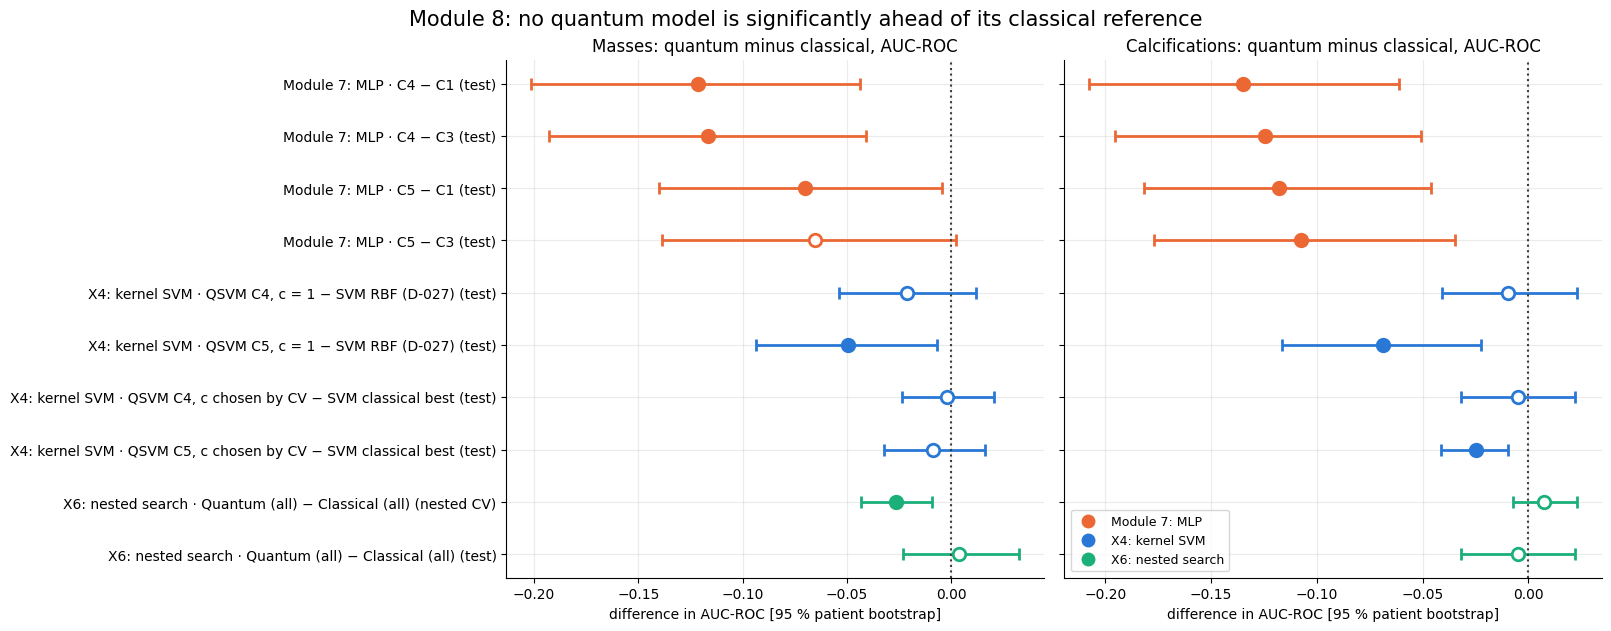

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.2), constrained_layout=True, sharey=True)
generic = lambda c: re.sub(r' \(gaussian \d+\)', '', re.sub(r'best c = [\d.]+', 'c chosen by CV', c))     # c and width differ by subset
label_of = lambda ft: key[key.finding_type == ft].apply(lambda r: f'{r.source} · {generic(r.comparison)} ({r.evaluation})', axis=1).tolist()
labels = label_of('mass')
check('the forest plot lists the same comparisons, in the same order, for both subsets', 0, labels == label_of('calcification'))
src_color = {'Module 7: MLP': '#eb6834', 'X4: kernel SVM': '#2a78d6', 'X6: nested search': '#1baf7a'}
for ax, ft in zip(axes, FINDINGS):
    part = key[key.finding_type == ft].reset_index(drop=True)
    for i, r in part.iterrows():
        c = src_color[r.source]
        ax.errorbar(r.difference, i, xerr=[[r.difference - r.ci_low], [r.ci_high - r.difference]], fmt='o', color=c, capsize=4,
                    markerfacecolor=c if r.interval_excludes_0 else 'white', markeredgewidth=2, markersize=9)
    ax.axvline(0, color=INK, ls=':', lw=1.5)
    if ft == 'mass':
        ax.set_yticks(range(len(labels)), labels)
        ax.invert_yaxis()
    ax.set(title=f'{TITLES[ft]}: quantum minus classical, AUC-ROC', xlabel='difference in AUC-ROC [95 % patient bootstrap]')
handles = [Line2D([], [], marker='o', ls='', color=c, markersize=9, label=s) for s, c in src_color.items()]
axes[1].legend(handles=handles, loc='lower left', fontsize=9)
fig.suptitle('Module 8: no quantum model is significantly ahead of its classical reference', fontsize=15)
fig.savefig(FIG_DIR / 'M8_classical_vs_quantum.png', dpi=180, bbox_inches='tight')
plt.show()

#### **3° Separability against classification (RF-21, OE-5)**

**a.** What Spearman's coefficient is, and what five conditions allow

**Spearman's coefficient is Pearson's correlation computed on ranks.** It asks whether two orderings agree, not whether the values are proportional, which is what RF-21 needs: Davies-Bouldin, Fisher $J$ and AUC-ROC live on different scales, but each of them orders the five conditions.

The report writes it as $\rho_s = 1-\dfrac{6\sum_i d_i^2}{n(n^2-1)}$ (eq. `spearman`). **That formula is exact only without ties**, and every separability metric of Module 6 ties C1 and C2 by construction (D-016). The general definition, used here, is Pearson's correlation of the average ranks: tied conditions share the mean of the ranks they occupy, and the formula of the report is the special case without ties. The equivalence is checked below.

**The exact null distribution.** If the two rankings were unrelated, each of the $5! = 120$ ways of assigning the classification ranks to the five conditions would be equally likely. The null distribution of $\rho_s$ is therefore a list of 120 values, with no approximation, and the two-sided p-value of an observed $\rho_s$ is the fraction of those values at least as extreme.

In [6]:
PERMS = np.array(list(itertools.permutations(range(5))))


def ranks(values, higher_is_better):
    # rank 1 = most separated or best classified; tied values share their average rank. Values are rounded to
    # 9 decimals first: the metrics of C1 and C2 differ only by floating-point noise (1e-14), and that is a tie (D-016)
    v = np.round(np.asarray(values, float), 9)
    return rankdata(-v if higher_is_better else v, method='average')


def rho(a, b):
    return float(np.corrcoef(a, b)[0, 1])


def exact_null(sep_ranks, cls_ranks):
    return np.array([rho(sep_ranks, cls_ranks[p]) for p in PERMS])


def spearman_exact(sep_ranks, cls_ranks):
    r = rho(sep_ranks, cls_ranks)
    return r, float(np.mean(np.abs(exact_null(sep_ranks, cls_ranks)) >= abs(r) - 1e-9))


base_ranks, tie_ranks = np.arange(1, 6, dtype=float), np.array([1.5, 1.5, 3, 4, 5])
err = max(abs(rho(base_ranks, base_ranks[p]) - (1 - 6 * ((base_ranks - base_ranks[p]) ** 2).sum() / (5 * (5 ** 2 - 1)))) for p in PERMS)
check('without ties, Pearson on ranks equals the formula of the report', err, err < 1e-12)
rng = np.random.default_rng(SEED)
err = 0.0
for _ in range(500):
    a, b = rng.integers(0, 3, 5).astype(float), rng.normal(size=5)
    if np.ptp(a) > 0:
        err = max(err, abs(rho(rankdata(a), rankdata(b)) - spearmanr(a, b)[0]))
check('with ties, Pearson on average ranks equals scipy.stats.spearmanr', err, err < 1e-12)
p_free, p_tie = spearman_exact(base_ranks, base_ranks)[1], spearman_exact(tie_ranks, base_ranks)[1]
check('no ties: the exact two-sided p of a perfect agreement is 2/120', p_free, np.isclose(p_free, 2 / 120))
check('C1 = C2 tied: the exact two-sided p of the best attainable agreement is 4/120', p_tie, np.isclose(p_tie, 4 / 120))

null_rows = []
for name, sep in [('no ties', base_ranks), ('C1 = C2 tied', tie_ranks)]:
    null = exact_null(sep, base_ranks)
    values, counts = np.unique(np.round(null, 9), return_counts=True)
    for v, c in zip(values, counts):
        null_rows.append({'separability_ranks': name, 'rho': v, 'orders': int(c), 'probability': c / len(PERMS),
                          'p_two_sided': float(np.mean(np.abs(null) >= abs(v) - 1e-9))})
null_table = pd.DataFrame(null_rows)
null_table.to_csv(RESULTS_DIR / '8_spearman_nula.csv', index=False)
print(f'best attainable rho with C1 = C2 tied: {rho(tie_ranks, base_ranks):.4f}')
display(null_table[(null_table.rho > 0) & (null_table.p_two_sided <= 0.25)].sort_values(['separability_ranks', 'rho'], ascending=[True, False]).round(4))

best attainable rho with C1 = C2 tied: 0.9747


,separability_ranks,rho,orders,probability,p_two_sided
50,C1 = C2 tied,0.9747,2,0.0167,0.0333
49,C1 = C2 tied,0.8721,4,0.0333,0.1000
48,C1 = C2 tied,0.8208,2,0.0167,0.1333
47,C1 = C2 tied,0.7182,2,0.0167,0.1667
20,no ties,1.0000,1,0.0083,0.0167
19,no ties,0.9000,4,0.0333,0.0833
18,no ties,0.8000,3,0.0250,0.1333
17,no ties,0.7000,6,0.0500,0.2333


**b.** The rankings and their correlations

- **Separability:** the three embedding metrics of Module 6, the family that describes the same vectors the MLP receives (H-013). The main sample is the 200-lesion subsample (D-028); the full training split is the robustness check. For Davies-Bouldin lower is better; for Fisher $J$ and the linear alignment, higher.
- **Classification:** the test AUC of Module 7, which is the main metric, and the cross-validated AUC.
- **$k = 12$** is the main analysis. **$k = 8$** repeats the comparison with the metrics of X3 and the classification of Module 7 on 8 qubits.

The **primary** value per subset and metric is subsample against test AUC at $k=12$; everything else is sensitivity. The table also says whether each ranking places the three classical conditions above the two quantum ones, which is the question behind OE-5.

In [7]:
SEP = [('davies_bouldin', 'Davies-Bouldin', False), ('fisher_j', 'Fisher J', True), ('kta_linear', 'linear KTA', True)]
top_block = lambda r: bool(r[:3].max() < r[3:].min())      # C1-C3 all ranked above C4 and C5


def classification_scores(ft, analysis):
    te = test7[(test7.finding_type == ft) & (test7.analysis == analysis)].set_index('condition').auc
    cv = cv_folds[(cv_folds.finding_type == ft) & (cv_folds.analysis == analysis) & (cv_folds.config == 'base')
                  & (cv_folds.seed == SEED)].groupby('condition').auc.mean()
    return {'test AUC': te.loc[CONDITIONS].to_numpy(), 'CV AUC': cv.loc[CONDITIONS].to_numpy()}


same = True
for _, p in emb_metrics.groupby(['finding_type', 'sample']):
    p = p.set_index('condition').loc[CONDITIONS]
    same &= bool((ranks(p.kta_linear, True) == ranks(p.kta_linear - p.la_null_mean, True)).all())
check('k = 12: ranking by the linear alignment equals ranking by its excess over the permutation mean (D-033)', 0, same)

rho_rows, rank_rows = [], []
for k, analysis, src in [(12, 'main', emb_metrics), (8, 'k8', x3_metrics[x3_metrics.k == 8])]:
    for ft in FINDINGS:
        cls = classification_scores(ft, analysis)
        for cls_name, scores in cls.items():
            rank_rows += [{'finding_type': ft, 'k': k, 'ranking': cls_name, 'condition': c, 'value': v, 'rank': r}
                          for c, v, r in zip(CONDITIONS, scores, ranks(scores, True))]
        for sample in ['subsample', 'full train']:
            part = src[(src.finding_type == ft) & (src['sample'] == sample)].set_index('condition').loc[CONDITIONS]
            for col, label, higher in SEP:
                sep_r = ranks(part[col], higher)
                rank_rows += [{'finding_type': ft, 'k': k, 'ranking': f'{label} ({sample})', 'condition': c, 'value': v, 'rank': r}
                              for c, v, r in zip(CONDITIONS, part[col], sep_r)]
                for cls_name, scores in cls.items():
                    cls_r = ranks(scores, True)
                    r, p = spearman_exact(sep_r, cls_r)
                    rho_rows.append({'finding_type': ft, 'k': k, 'sample': sample, 'metric': label, 'classification': cls_name,
                                     'rho': r, 'p_exact_two_sided': p,
                                     'separability_ranks': ' '.join(f'{c}:{x:g}' for c, x in zip(CONDITIONS, sep_r)),
                                     'classification_ranks': ' '.join(f'{c}:{x:g}' for c, x in zip(CONDITIONS, cls_r)),
                                     'classical_first_separability': top_block(sep_r), 'classical_first_classification': top_block(cls_r),
                                     'primary': k == 12 and sample == 'subsample' and cls_name == 'test AUC'})
rho_table, rank_table = pd.DataFrame(rho_rows), pd.DataFrame(rank_rows)
sep_only = rank_table[~rank_table.ranking.isin(['test AUC', 'CV AUC'])].pivot_table(index=['finding_type', 'k', 'ranking'], columns='condition', values='rank')
check('every separability ranking ties C1 and C2 (null control)', (sep_only.C1 - sep_only.C2).abs().max(), (sep_only.C1 == sep_only.C2).all())
rho_table.to_csv(RESULTS_DIR / '8_spearman.csv', index=False)
rank_table.to_csv(RESULTS_DIR / '8_rangos.csv', index=False)
print('Primary values: 200-lesion subsample against test AUC, k = 12')
display(rho_table[rho_table.primary][['finding_type', 'metric', 'rho', 'p_exact_two_sided', 'separability_ranks', 'classification_ranks',
                                      'classical_first_separability', 'classical_first_classification']].round(3))
print('All values: median rho and range per subset and k')
display(rho_table.groupby(['finding_type', 'k']).rho.agg(['median', 'min', 'max', 'count']).round(3))
display(rank_table[rank_table.k == 12].pivot_table(index=['finding_type', 'ranking'], columns='condition', values='rank'))

Primary values: 200-lesion subsample against test AUC, k = 12


,finding_type,metric,rho,p_exact_two_sided,separability_ranks,classification_ranks,classical_first_separability,classical_first_classification
0,mass,Davies-Bouldin,0.718,0.167,C1:1.5 C2:1.5 C3:3 C4:4 C5:5,C1:1 C2:3 C3:2 C4:5 C5:4,True,True
2,mass,Fisher J,0.821,0.133,C1:2.5 C2:2.5 C3:1 C4:5 C5:4,C1:1 C2:3 C3:2 C4:5 C5:4,True,True
4,mass,linear KTA,0.718,0.167,C1:1.5 C2:1.5 C3:3 C4:4 C5:5,C1:1 C2:3 C3:2 C4:5 C5:4,True,True
12,calcification,Davies-Bouldin,0.975,0.033,C1:1.5 C2:1.5 C3:3 C4:5 C5:4,C1:2 C2:1 C3:3 C4:5 C5:4,True,True
14,calcification,Fisher J,0.667,0.267,C1:2.5 C2:2.5 C3:1 C4:5 C5:4,C1:2 C2:1 C3:3 C4:5 C5:4,True,True
16,calcification,linear KTA,0.975,0.033,C1:1.5 C2:1.5 C3:3 C4:5 C5:4,C1:2 C2:1 C3:3 C4:5 C5:4,True,True


All values: median rho and range per subset and k


median    min    max  count
finding_type  k                              
calcification 8    0.821  0.821  0.821     12
              12   0.872  0.667  0.975     12
mass          8    0.821  0.667  0.975     12
              12   0.769  0.718  0.821     12

condition                                   C1   C2   C3   C4   C5
finding_type  ranking                                             
calcification CV AUC                       2.0  1.0  3.0  5.0  4.0
              Davies-Bouldin (full train)  1.5  1.5  3.0  4.0  5.0
              Davies-Bouldin (subsample)   1.5  1.5  3.0  5.0  4.0
              Fisher J (full train)        1.5  1.5  3.0  4.0  5.0
              Fisher J (subsample)         2.5  2.5  1.0  5.0  4.0
              linear KTA (full train)      1.5  1.5  3.0  4.0  5.0
              linear KTA (subsample)       1.5  1.5  3.0  5.0  4.0
              test AUC                     2.0  1.0  3.0  5.0  4.0
mass          CV AUC                       1.0  3.0  2.0  4.0  5.0
              Davies-Bouldin (full train)  1.5  1.5  3.0  4.0  5.0
              Davies-Bouldin (subsample)   1.5  1.5  3.0  4.0  5.0
              Fisher J (full train)        1.5  1.5  3.0  5.0  4.0
              Fisher J (subsample)         2.5  2.5  1.0  5.0  4.0
              linear KTA (full train)      1.5  1.5  3.0  4.0  5.0
              linear KTA (subsample)       1.5  1.5  3.0  4.0  5.0
              test AUC                     1.0  3.0  2.0  5.0  4.0

**c.** The same question for the kernel family, as a description only. Module 6 measured the alignment of three kernels at $c=1$, the RBF of D-027 and the fidelity kernels of C4 and C5, and X4 classified with exactly those three kernels in an SVM. With three objects $\rho_s$ can only take the values $\pm 1$ and $\pm 0.5$, and its smallest two-sided p-value is $2/6 \approx 0.33$, so the only useful reading is whether the two orders coincide.

In [8]:
krows = []
for ft in FINDINGS:
    k_ft = kta[kta.finding_type == ft]
    excess = [k_ft[k_ft.kernel == 'K_C'].excess_centered.iloc[0]] + [k_ft[(k_ft.kernel == q) & (k_ft.c == 1.0)].excess_centered.iloc[0] for q in QUANTUM]
    x4 = x4_test[x4_test.finding_type == ft].set_index('model').auc
    auc = [x4['SVM RBF (D-027)'], x4['QSVM C4, c = 1'], x4['QSVM C5, c = 1']]
    for name, e, a, re_, ra in zip(['RBF (D-027)', 'C4, c = 1', 'C5, c = 1'], excess, auc, ranks(excess, True), ranks(auc, True)):
        krows.append({'finding_type': ft, 'kernel': name, 'kta_excess_centered': e, 'rank_alignment': re_, 'svm_test_auc_X4': a, 'rank_auc': ra})
kernel_ranks = pd.DataFrame(krows)
kernel_ranks.to_csv(RESULTS_DIR / '8_rangos_kernel.csv', index=False)
for ft in FINDINGS:
    part = kernel_ranks[kernel_ranks.finding_type == ft]
    print(f'{TITLES[ft]:15s}: same order in alignment and in SVM test AUC: {bool((part.rank_alignment == part.rank_auc).all())}')
display(kernel_ranks.round(4))

Masses         : same order in alignment and in SVM test AUC: False
Calcifications : same order in alignment and in SVM test AUC: False


,finding_type,kernel,kta_excess_centered,rank_alignment,svm_test_auc_X4,rank_auc
0,mass,RBF (D-027),0.0491,1.0,0.6491,1.0
1,mass,"C4, c = 1",0.0030,3.0,0.6279,2.0
2,mass,"C5, c = 1",0.0051,2.0,0.5995,3.0
3,calcification,RBF (D-027),0.1515,1.0,0.7691,1.0
4,calcification,"C4, c = 1",0.0062,3.0,0.7588,2.0
5,calcification,"C5, c = 1",0.0066,2.0,0.7005,3.0


**d.** Figures: each condition's separability against its test AUC, and the exact null distribution of $\rho_s$ with the observed primary values

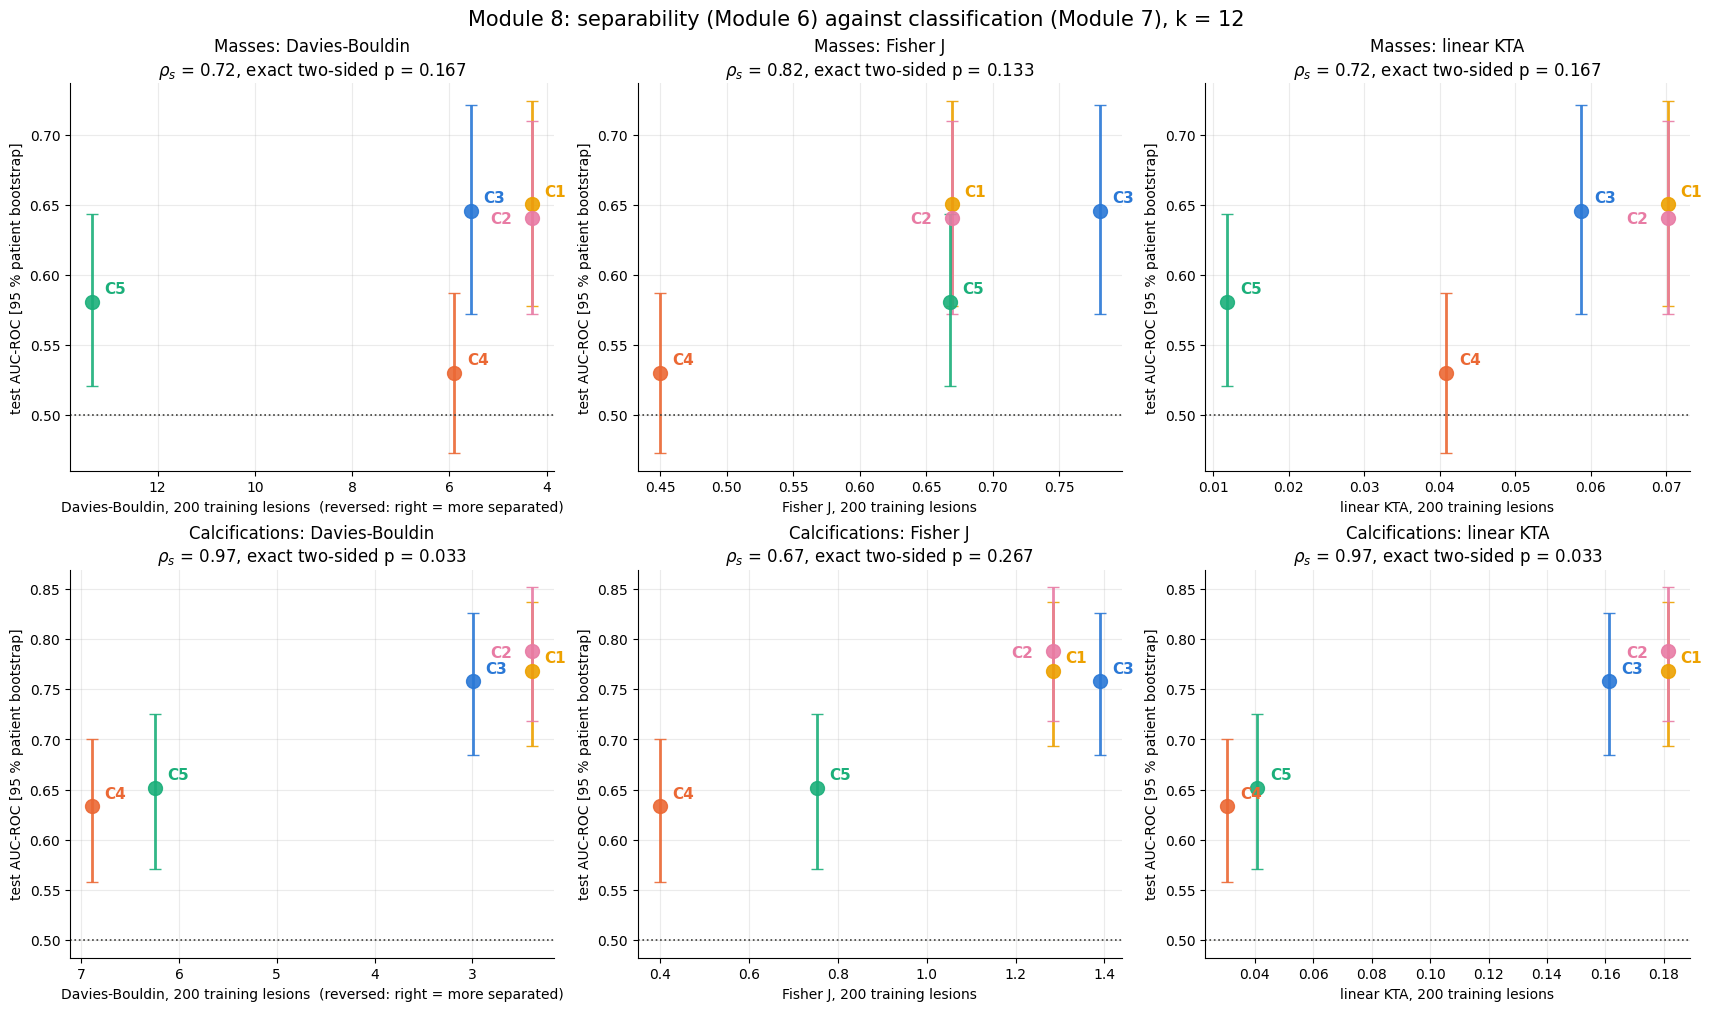

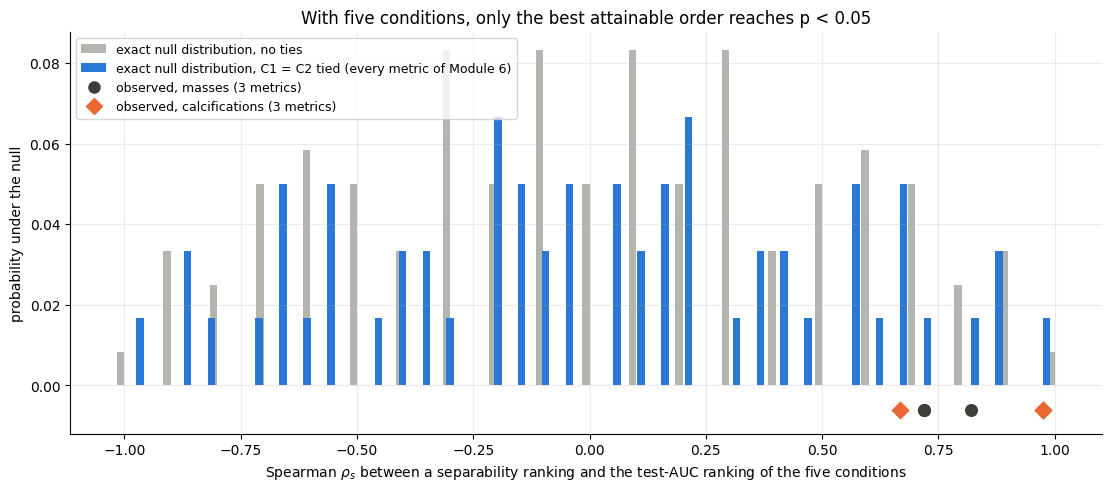

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10), constrained_layout=True)
for row, ft in enumerate(FINDINGS):
    te = test7[(test7.finding_type == ft) & (test7.analysis == 'main')].set_index('condition').loc[CONDITIONS]
    part = emb_metrics[(emb_metrics.finding_type == ft) & (emb_metrics['sample'] == 'subsample')].set_index('condition').loc[CONDITIONS]
    for col, (metric, label, higher) in enumerate(SEP):
        ax = axes[row, col]
        for cond in CONDITIONS:
            x, y = part.loc[cond, metric], te.loc[cond, 'auc']
            ax.errorbar(x, y, yerr=[[y - te.loc[cond, 'auc_ci_low']], [te.loc[cond, 'auc_ci_high'] - y]], fmt='o', color=COLORS[cond],
                        markersize=10, capsize=4, alpha=0.9)
            ax.annotate(cond, (x, y), textcoords='offset points', xytext=(-30, -4) if cond == 'C2' else (9, 6),   # C1 and C2 share x
                        fontsize=11, color=COLORS[cond], fontweight='bold')
        if not higher:
            ax.invert_xaxis()
        r = rho_table[rho_table.primary & (rho_table.finding_type == ft) & (rho_table.metric == label)].iloc[0]
        ax.axhline(0.5, color=INK, ls=':', lw=1.2)
        ax.set(title=f'{TITLES[ft]}: {label}\n$\\rho_s$ = {r.rho:.2f}, exact two-sided p = {r.p_exact_two_sided:.3f}',
               xlabel=f'{label}, 200 training lesions' + ('  (reversed: right = more separated)' if not higher else ''),
               ylabel='test AUC-ROC [95 % patient bootstrap]')
fig.suptitle('Module 8: separability (Module 6) against classification (Module 7), k = 12', fontsize=15)
fig.savefig(FIG_DIR / 'M8_spearman.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.8), constrained_layout=True)
for name, sep, color, off in [('no ties', base_ranks, '#b5b5b0', -0.008), ('C1 = C2 tied (every metric of Module 6)', tie_ranks, '#2a78d6', 0.008)]:
    null = exact_null(sep, base_ranks)
    v, c = np.unique(np.round(null, 6), return_counts=True)
    ax.bar(v + off, c / len(PERMS), width=0.016, color=color, label=f'exact null distribution, {name}')
marks = {'mass': ('o', INK), 'calcification': ('D', '#eb6834')}
for r in rho_table[rho_table.primary].itertuples():
    m, c = marks[r.finding_type]
    ax.scatter(r.rho, -0.006, marker=m, s=70, color=c, zorder=3, clip_on=False)
handles = ax.get_legend_handles_labels()[0] + [Line2D([], [], marker=m, ls='', color=c, markersize=8, label=f'observed, {TITLES[f].lower()} (3 metrics)')
                                               for f, (m, c) in marks.items()]
ax.legend(handles=handles, fontsize=9, loc='upper left')
ax.set(xlabel='Spearman $\\rho_s$ between a separability ranking and the test-AUC ranking of the five conditions',
       ylabel='probability under the null', title='With five conditions, only the best attainable order reaches p < 0.05', ylim=(-0.012, None))
fig.savefig(FIG_DIR / 'M8_spearman_null.png', dpi=180, bbox_inches='tight')
plt.show()

#### **4° Masses against calcifications**

**a.** A reference for the separability of the classes in the descriptors written by the radiologists

The EDA expected masses to be the easier subset: their benign and malignant cases differ in shape and margins (OVAL and CIRCUMSCRIBED against IRREGULAR and SPICULATED), while the most frequent calcification type (PLEOMORPHIC) appears in both classes. Modules 6 and 7 found the opposite with the radiomic features. To tell whether the difference lies in the classes or in the features, the same logistic regression is fitted on two inputs, with the folds of Module 4:

- the categorical descriptors of each lesion in the CBIS-DDSM files: shape and margins for masses, type and distribution for calcifications;
- the 12 angles of Module 4.

The descriptors are not a competitor. A radiologist wrote them while looking at the image, so they are not available to an automatic system. They measure how separable the classes are in the vocabulary of the radiologist. `assessment` (BI-RADS) and `subtlety` are left out, because BI-RADS is already a judgement of malignancy.

In [10]:
DESC = {'mass': ('mass', 'Mass', ['mass shape', 'mass margins']), 'calcification': ('calc', 'Calc', ['calc type', 'calc distribution'])}
desc_rows = []
for ft, (kind, prefix, columns) in DESC.items():
    parts = []
    for split, tag in [('train', 'Training'), ('test', 'Test')]:
        csv = pd.read_csv(DATA / f'{kind}_case_description_{split}_set.csv')
        case_id = (prefix + '-' + tag + '_' + csv['patient_id'] + '_' + csv['left or right breast'] + '_'
                   + csv['image view'] + '_' + csv['abnormality id'].astype(str))
        parts.append(csv[columns].fillna('MISSING').astype(str).assign(case_id=case_id.to_numpy()))
    d = pd.concat(parts, ignore_index=True)
    dup = int(d.case_id.duplicated().sum())
    check(f'{ft}: case identifiers in the CBIS-DDSM files are unique', dup, dup == 0)
    m4 = pd.read_parquet(M4_DIR / f'x_{ft}.parquet')
    tr = m4[m4.split == 'train'].merge(d.drop_duplicates('case_id'), on='case_id', how='left', validate='one_to_one')
    missing = int(tr[columns].isna().any(axis=1).sum())
    check(f'{ft}: every training lesion has its radiologist descriptors', missing, missing == 0)
    y, folds = tr.label.to_numpy(int), tr.fold.to_numpy(int)
    inputs = [('radiologist descriptors', tr[columns], lambda: make_pipeline(OneHotEncoder(handle_unknown='ignore'),
                                                                              LogisticRegression(class_weight='balanced', max_iter=5000))),
              ('12 angles of Module 4', tr[[f'x_{j:02d}' for j in range(1, 13)]], lambda: make_pipeline(StandardScaler(),
                                                                                                        LogisticRegression(class_weight='balanced', max_iter=5000)))]
    for name, X, model in inputs:
        aucs = []
        for f in range(N_FOLDS):
            fitted = model().fit(X[folds != f], y[folds != f])
            aucs.append(roc_auc_score(y[folds == f], fitted.predict_proba(X[folds == f])[:, 1]))
        desc_rows.append({'finding_type': ft, 'features': name, 'cv_auc_mean': np.mean(aucs), 'cv_auc_std': np.std(aucs, ddof=1),
                          'categories': int(sum(tr[c].nunique() for c in columns)) if name.startswith('radiologist') else 12})
    for name in ['all 67', '12 of Module 4 (fixed)']:
        r = x1_auc[(x1_auc.finding_type == ft) & (x1_auc.model == 'LR') & (x1_auc.feature_set == name)].iloc[0]
        desc_rows.append({'finding_type': ft, 'features': f'X1: {name} radiomic features', 'cv_auc_mean': r.auc, 'cv_auc_std': r.auc_std, 'categories': np.nan})
descriptors = pd.DataFrame(desc_rows)
descriptors.to_csv(RESULTS_DIR / '8_descriptores_radiologo.csv', index=False)
display(descriptors.round(3))

,finding_type,features,cv_auc_mean,cv_auc_std,categories
0,mass,radiologist descriptors,0.872,0.023,35.0
1,mass,12 angles of Module 4,0.668,0.064,12.0
2,mass,X1: all 67 radiomic features,0.693,0.039,NaN
3,mass,X1: 12 of Module 4 (fixed) radiomic features,0.650,0.056,NaN
4,calcification,radiologist descriptors,0.825,0.017,56.0
5,calcification,12 angles of Module 4,0.745,0.029,12.0
6,calcification,X1: all 67 radiomic features,0.800,0.028,NaN
7,calcification,X1: 12 of Module 4 (fixed) radiomic features,0.758,0.025,NaN


**b.** The two subsets side by side: data, discriminative power of the features, classification and separability

In [11]:
mv = []


def add(quantity, values, source):
    mv.append({'quantity': quantity, 'mass': values['mass'], 'calcification': values['calcification'], 'source': source})


fmt_ci = lambda v, lo, hi: f'{v:.3f} [{lo:.2f}, {hi:.2f}]'
tr_frames = {ft: frames[ft][frames[ft].split == 'train'] for ft in FINDINGS}
add('training / test lesions', {ft: f"{len(tr_frames[ft])} / {int(frames[ft].split.eq('test').sum())}" for ft in FINDINGS}, 'Module 4')
add('malignant fraction, train', {ft: round(tr_frames[ft].label.mean(), 3) for ft in FINDINGS}, 'Module 4')
eff = effect[effect.variant == 'raw']
add('largest |d| among the 67 features, train', {ft: f"{eff[eff.finding_type == ft].abs_d.max():.2f} ({eff.loc[eff[eff.finding_type == ft].abs_d.idxmax(), 'feature'].replace('original_', '')})"
                                               for ft in FINDINGS}, '3_tamano_efecto.csv')
lr = descriptors.set_index(['finding_type', 'features']).cv_auc_mean
add('LR on radiologist descriptors, CV AUC', {ft: round(lr[(ft, 'radiologist descriptors')], 3) for ft in FINDINGS}, 'this module')
add('LR on the 67 radiomic features, CV AUC', {ft: round(lr[(ft, 'X1: all 67 radiomic features')], 3) for ft in FINDINGS}, 'X1')
add('LR on the 12 angles, CV AUC', {ft: round(lr[(ft, '12 angles of Module 4')], 3) for ft in FINDINGS}, 'this module')
for cond in ['C1', 'C3', 'C4', 'C5']:
    add(f'MLP on {cond}, test AUC', {ft: fmt_ci(*rf20[(rf20.finding_type == ft) & (rf20.condition == cond)][['test_auc', 'test_auc_ci_low', 'test_auc_ci_high']].iloc[0])
                                     for ft in FINDINGS}, 'Module 7')
for q in QUANTUM:
    add(f'{q} − C1, test AUC', {ft: fmt_ci(*key[(key.finding_type == ft) & (key.comparison == f'{q} − C1')][['difference', 'ci_low', 'ci_high']].iloc[0])
                                for ft in FINDINGS}, 'Module 7')
add('QSVM C4 (c = 1) − SVM RBF, test AUC', {ft: fmt_ci(*key[(key.finding_type == ft) & (key.comparison == 'QSVM C4, c = 1 − SVM RBF (D-027)')][['difference', 'ci_low', 'ci_high']].iloc[0])
                                            for ft in FINDINGS}, 'X4')
for cond in ['C1', 'C4', 'C5']:
    add(f'Fisher J on the full train, {cond}', {ft: round(emb_metrics[(emb_metrics.finding_type == ft) & (emb_metrics['sample'] == 'full train')
                                                                     & (emb_metrics.condition == cond)].fisher_j.iloc[0], 3) for ft in FINDINGS}, 'Module 6')
for name, kern, c in [('RBF', 'K_C', None), ('C4', 'C4', 1.0), ('C5', 'C5', 1.0)]:
    sel = lambda ft: kta[(kta.finding_type == ft) & (kta.kernel == kern) & ((kta.c == c) if c else kta.c.isna())].excess_centered.iloc[0]
    add(f'excess of centered KTA, {name}' + (', c = 1' if c else ''), {ft: round(sel(ft), 4) for ft in FINDINGS}, 'Module 6')
for q in QUANTUM:
    add(f'median off-diagonal kernel value, {q}, c = 1', {ft: f"{conc[(conc.finding_type == ft) & (conc.kernel == q) & (conc.c == 1.0)].median_off_diagonal.iloc[0]:.1e}"
                                                         for ft in FINDINGS}, 'Module 5')
    add(f'geometric difference g, {q}, c = 1', {ft: round(gsum[(gsum.finding_type == ft) & (gsum['map'] == q) & (gsum.c == 1.0)].g_min.iloc[0], 2)
                                               for ft in FINDINGS}, 'Module 6')
    add(f'effective dimension of 200, {q}, c = 1', {ft: round(dims[(dims.finding_type == ft) & (dims.kernel == q) & (dims.c == 1.0)].effective_dimension.iloc[0], 1)
                                                   for ft in FINDINGS}, 'Module 6')
masses_vs_calc = pd.DataFrame(mv)
masses_vs_calc.to_csv(RESULTS_DIR / '8_masas_vs_calcificaciones.csv', index=False)
display(masses_vs_calc)

,quantity,mass,calcification,source
0,training / test lesions,1318 / 378,1546 / 326,Module 4
1,"malignant fraction, train",0.483,0.352,Module 4
2,"largest |d| among the 67 features, train",0.50 (firstorder_Maximum),0.82 (shape2D_MinorAxisLength),3_tamano_efecto.csv
3,"LR on radiologist descriptors, CV AUC",0.872,0.825,this module
4,"LR on the 67 radiomic features, CV AUC",0.693,0.8,X1
5,"LR on the 12 angles, CV AUC",0.668,0.745,this module
6,"MLP on C1, test AUC","0.651 [0.58, 0.72]","0.769 [0.69, 0.84]",Module 7
7,"MLP on C3, test AUC","0.646 [0.57, 0.72]","0.758 [0.68, 0.83]",Module 7
8,"MLP on C4, test AUC","0.530 [0.47, 0.59]","0.633 [0.56, 0.70]",Module 7
9,"MLP on C5, test AUC","0.581 [0.52, 0.64]","0.652 [0.57, 0.73]",Module 7


#### **5° Constraints of the simulator (RF-22, OE-6)**

Two kinds of statement are mixed in this section, and the report should keep them apart:

- **Properties of the formalism**, which would hold on any machine: the state of $k$ qubits has $2^k$ amplitudes; a measurement returns one bit string, so an expectation value is estimated with an error that falls as $1/\sqrt{n}$ in the number of shots $n$; the parameter-shift rule needs two circuit evaluations per parameter.
- **Properties of the simulator or of Qiskit**: how long Aer takes per state on this machine, how much memory it uses, and the shortcuts that only exist in simulation, such as reading the state vector directly (H-032).

**a.** Time per sample, and the cost of training θ (benchmark B1, Module 5)

B1 timed the forward pass and the parameter-shift backward pass through `EstimatorQNN`, and projected the cost of training θ for 50 epochs on both subsets (Architecture A). Module 5 computed the embeddings with θ fixed (Architecture B, D-014) by evolving the state vector directly.

In [12]:
cost = b1[b1.feature_map == 'zz'][['k', 'reps', 'n_weights', 'fwd_per_sample_s', 'bwd_per_sample_s', 'total_both_h']].copy()
cost['evaluations_per_gradient'] = 2 * cost.n_weights
cost = cost.rename(columns={'total_both_h': 'training_hours_50_epochs_both_subsets_per_map'})
display(cost.round(3))
display(b1_arch.round(3))
m5_ms = {(ft, q): 1000 * a5[(a5.finding_type == ft) & (a5.condition == q)].total_time_seconds.iloc[0] / len(frames[ft]) for ft in FINDINGS for q in QUANTUM}
for (ft, q), v in m5_ms.items():
    print(f'Module 5, direct statevector, {TITLES[ft]:14s} {q}: {v:.1f} ms per lesion')
sv = t5b[t5b.kernel.str.startswith('FidelityStatevectorKernel')].seconds.mean()
fq = t5b[t5b.kernel.str.startswith('FidelityQuantumKernel')].seconds.mean()
pairs200, pairs10 = 200 * 199 / 2, 10 * 9 / 2
print(f'Kernel 200 x 200 with the statevector shortcut: {sv:.2f} s; with compute-uncompute circuits: {fq:.2f} s for 10 x 10, '
      f'projected {fq / pairs10 * pairs200 / 60:.0f} min for 200 x 200 ({fq / pairs10 / (sv / pairs200):.0f} times slower per pair)')

,k,reps,n_weights,fwd_per_sample_s,bwd_per_sample_s,training_hours_50_epochs_both_subsets_per_map,evaluations_per_gradient
0,8,1,16,0.017,0.587,24.025,32
1,8,2,24,0.021,0.975,39.617,48
2,8,3,32,0.020,1.379,55.622,64
3,12,1,24,0.093,4.705,190.864,48
4,12,2,36,0.101,7.358,296.686,72
5,12,3,48,0.113,10.654,428.279,96
6,16,1,32,1.056,65.616,2652.097,64
7,16,2,48,1.101,110.564,4441.780,96
8,16,3,64,1.222,149.675,6002.349,128


,k,fwd_ms,arch_A_hours,arch_B_hours,speedup
0,8,16.465,48.050,0.033,1472.203
1,12,100.516,381.727,0.199,1915.860
2,16,1241.632,5304.194,2.461,2155.133


Module 5, direct statevector, Masses         C4: 7.8 ms per lesion
Module 5, direct statevector, Masses         C5: 8.4 ms per lesion
Module 5, direct statevector, Calcifications C4: 7.5 ms per lesion
Module 5, direct statevector, Calcifications C5: 8.6 ms per lesion
Kernel 200 x 200 with the statevector shortcut: 1.55 s; with compute-uncompute circuits: 4.99 s for 10 x 10, projected 37 min for 200 x 200 (1422 times slower per pair)


**b.** The largest viable number of qubits: a sweep of `AerSimulator` up to the memory of this machine

**Why memory is the wall.** A statevector simulator stores the $2^k$ complex amplitudes of the state, 16 bytes each. Each added qubit doubles the memory and, at least, the time of every gate. The sweep times one state of the C4 circuit (feature map and ansatz, reps = 1) for even $k$ from 8 to 28. The circuit stores only the $k$ values $\langle Z_i\rangle$, not the state, so that returning the result does not double the memory. The run stops before a state would take more than 30 % of the RAM.

The first check validates the simulator: on a real lesion and with the θ of the design, Aer must give the same $\langle Z_i\rangle$ as the embedding of Module 5.

In [13]:
theta = np.array(json.loads((M5_DIR / 'emb_meta.json').read_text())['theta'])
ansatz = real_amplitudes(K, reps=1)
maps = {'C4': zz_feature_map(K, reps=1), 'C5': pauli_feature_map(K, reps=1, paulis=['Y', 'ZZ'])}


def bound_circuit(fm, an, x, th):
    values = {p: float(v) for p, v in zip(fm.parameters, x)}
    values.update({p: float(v) for p, v in zip(an.parameters, th)})
    return fm.compose(an).assign_parameters(values, inplace=False)


def with_local_z(qc):
    qc = qc.copy()
    for i in range(qc.num_qubits):
        qc.save_expectation_value(SparsePauliOp('Z'), [i], label=f'z{i}')
    return qc


sim = AerSimulator(method='statevector', seed_simulator=SEED)
x0 = frames['mass'][cols('C1')].to_numpy(float)[0]
res = sim.run(transpile(with_local_z(bound_circuit(maps['C4'], ansatz, x0, theta)), sim)).result().data()
err = np.abs(np.array([res[f'z{i}'] for i in range(K)]) - frames['mass'][cols('C4')].to_numpy()[0]).max()
check('AerSimulator reproduces the C4 embedding of Module 5 on a real lesion', err, err < 1e-10)

rng = np.random.default_rng(SEED)
sweep = []
for k in QUBIT_SWEEP:
    need = 16 * 2 ** k
    if need > 0.3 * RAM_BYTES:
        print(f'k = {k}: skipped, one state needs {need / 2**30:.1f} GiB')
        continue
    fm, an = zz_feature_map(k, reps=1), real_amplitudes(k, reps=1)
    tqc = transpile(with_local_z(bound_circuit(fm, an, rng.uniform(0, np.pi, k), rng.uniform(0, 2 * np.pi, an.num_parameters))), sim)
    times = []
    for _ in range(5 if k <= 20 else 1):
        t0 = time.perf_counter()
        sim.run(tqc).result()
        times.append(time.perf_counter() - t0)
    sweep.append({'k': k, 'seconds_per_state': float(np.median(times)), 'repeats': len(times), 'state_bytes': need,
                  'cx_gates': int(tqc.count_ops().get('cx', 0))})
    print(f'k = {k:2d}: {np.median(times):9.4f} s per state | state {need / 2**20:10.1f} MiB | {sweep[-1]["cx_gates"]} CX')
sweep = pd.DataFrame(sweep)

k =  8:    0.0012 s per state | state        0.0 MiB | 60 CX
k = 10:    0.0019 s per state | state        0.0 MiB | 96 CX


k = 12:    0.0029 s per state | state        0.1 MiB | 140 CX
k = 14:    0.0065 s per state | state        0.2 MiB | 192 CX


k = 16:    0.0349 s per state | state        1.0 MiB | 252 CX


k = 18:    0.1071 s per state | state        4.0 MiB | 320 CX


k = 20:    0.3924 s per state | state       16.0 MiB | 396 CX


k = 22:    1.2471 s per state | state       64.0 MiB | 480 CX


k = 24:    4.1339 s per state | state      256.0 MiB | 572 CX


k = 26:   13.7479 s per state | state     1024.0 MiB | 672 CX


k = 28:   74.7769 s per state | state     4096.0 MiB | 780 CX


**c.** From seconds per state to the tasks of this work. For each $k$, the time per state $t_k$ is turned into the time of four tasks on this machine. Inside the sweep, $t_k$ is measured or interpolated between measured points; beyond it, it follows the exponential fitted on $k \ge 20$. The four tasks are:

- **embedding:** $3{,}568$ lesions × 2 feature maps, Architecture B;
- **kernel, compute-uncompute:** $N(N-1)/2$ circuits for $N = 200$. The circuit is about twice as deep as one state, so each one is counted as $2t_k$. This is the only route on hardware;
- **kernel, statevector shortcut:** $N$ states and their inner products. It needs all $N$ states in memory at once, $N\cdot 16\cdot 2^k$ bytes, unless they are recomputed in blocks;
- **training θ (Architecture A):** 50 epochs over the $2{,}864$ training lesions. The parameter-shift rule needs $1 + 2m$ evaluations per lesion, with $m = 2k$ parameters in the ansatz.

These are **lower bounds**: they count only the simulation, not the overhead of the primitives that B1 measured. A task is viable here if it finishes within 24 h and its memory fits in half of the RAM.

In [14]:
fit_k = sweep[sweep.k >= 20]
slope, intercept = np.polyfit(fit_k.k, np.log2(fit_k.seconds_per_state), 1)
measured = dict(zip(sweep.k, sweep.seconds_per_state))
N_LESIONS, N_TRAIN, N_KERNEL = sum(len(f) for f in frames.values()), sum(len(t) for t in tr_frames.values()), 200
proj = []
k_max = int(sweep.k.max())
for k in range(8, 41):
    # inside the sweep: log-linear interpolation between measured points; beyond it: the fitted exponential
    t = 2 ** (np.interp(k, sweep.k, np.log2(sweep.seconds_per_state)) if k <= k_max else slope * k + intercept)
    proj.append({'k': k, 'measured': k in measured, 'seconds_per_state': t, 'state_GiB': 16 * 2 ** k / 2**30,
                 'embedding_hours': N_LESIONS * 2 * t / 3600,
                 'kernel_compute_uncompute_hours': N_KERNEL * (N_KERNEL - 1) / 2 * 2 * t / 3600,
                 'kernel_statevector_memory_GiB': N_KERNEL * 16 * 2 ** k / 2**30,
                 'training_A_hours_per_map': EPOCHS_A * N_TRAIN * (1 + 2 * 2 * k) * t / 3600})
proj = pd.DataFrame(proj)
proj.to_csv(RESULTS_DIR / '8_oe6_qubits.csv', index=False)
fits = lambda col_mem: proj[col_mem] <= RAM_BYTES / 2 / 2**30
limits = {'one state in memory (half of the RAM)': int(proj[fits('state_GiB')].k.max()),
          'embedding of every lesion in 24 h': int(proj[fits('state_GiB') & (proj.embedding_hours <= 24)].k.max()),
          'kernel 200 x 200, compute-uncompute, in 24 h': int(proj[fits('state_GiB') & (proj.kernel_compute_uncompute_hours <= 24)].k.max()),
          'kernel 200 x 200, statevector shortcut, all states in memory': int(proj[fits('kernel_statevector_memory_GiB')].k.max()),
          'training theta by parameter-shift in 24 h (one map)': int(proj[fits('state_GiB') & (proj.training_A_hours_per_map <= 24)].k.max())}
print(f'fitted growth for k >= 20: x{2 ** slope:.2f} per added qubit')
for name, k in limits.items():
    print(f'  largest viable k, {name}: {k}')
display(proj[proj.k.isin([8, 12, 16, 20, 24, 28, 30, 32])].round(4))

fitted growth for k >= 20: x1.91 per added qubit
  largest viable k, one state in memory (half of the RAM): 29
  largest viable k, embedding of every lesion in 24 h: 25
  largest viable k, kernel 200 x 200, compute-uncompute, in 24 h: 22
  largest viable k, kernel 200 x 200, statevector shortcut, all states in memory: 21
  largest viable k, training theta by parameter-shift in 24 h (one map): 14


,k,measured,seconds_per_state,state_GiB,embedding_hours,kernel_compute_uncompute_hours,kernel_statevector_memory_GiB,training_A_hours_per_map
0,8,True,0.0012,0.0000,0.0024,0.0137,0.0008,1.622000e+00
4,12,True,0.0029,0.0001,0.0058,0.0324,0.0122,5.704800e+00
8,16,True,0.0349,0.0010,0.0693,0.3863,0.1953,9.034780e+01
12,20,True,0.3924,0.0156,0.7778,4.3383,3.1250,1.264351e+03
16,24,True,4.1339,0.2500,8.1942,45.7022,50.0000,1.595029e+04
20,28,True,74.7769,4.0000,148.2244,826.7000,800.0000,3.361138e+05
22,30,False,220.9619,16.0000,437.9956,2442.8564,3200.0000,1.063514e+06
24,32,False,802.7061,64.0000,1591.1418,8874.3614,12800.0000,4.118952e+06


**d.** Figure: measured time per state, and the projected time of each task

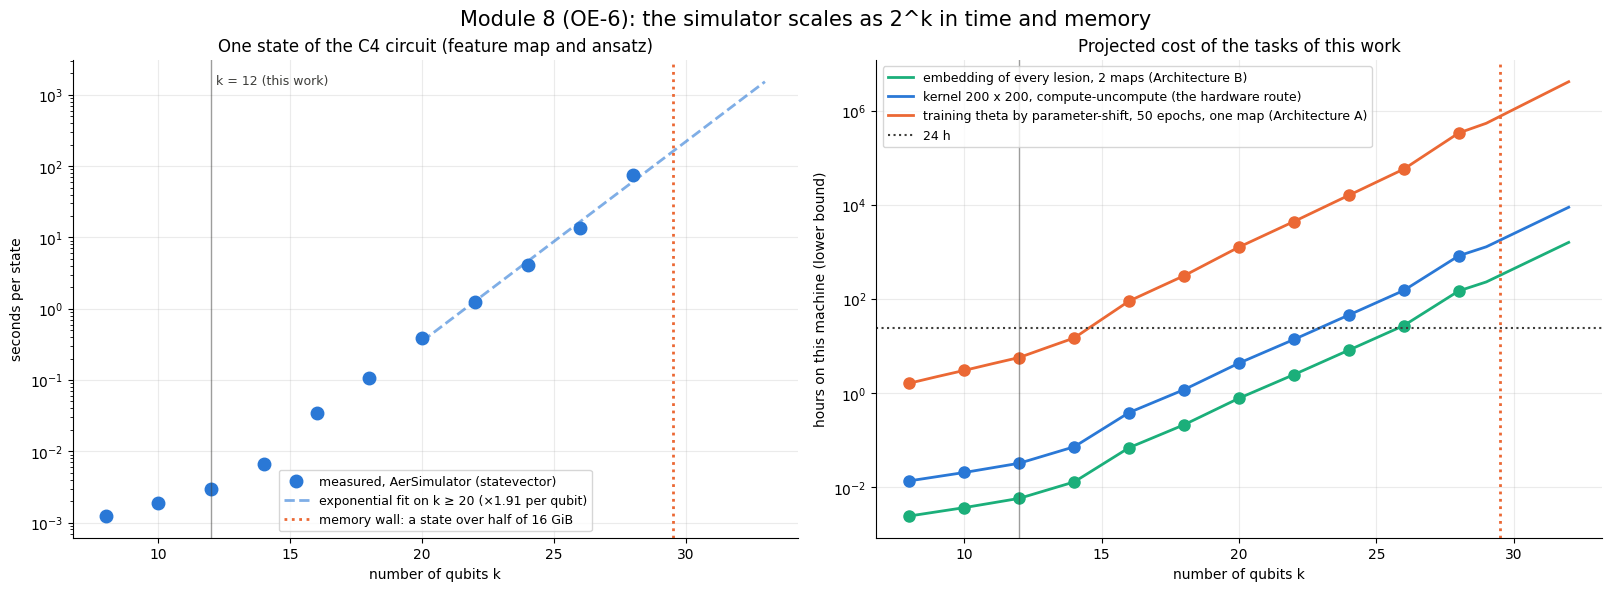

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), constrained_layout=True)
ax = axes[0]
ax.plot(sweep.k, sweep.seconds_per_state, 'o', color='#2a78d6', markersize=9, label='measured, AerSimulator (statevector)')
kk = np.arange(20, 34)
ax.plot(kk, 2 ** (slope * kk + intercept), '--', color='#2a78d6', alpha=0.6, label=f'exponential fit on k ≥ 20 (×{2 ** slope:.2f} per qubit)')
ax.axvline(limits['one state in memory (half of the RAM)'] + 0.5, color='#eb6834', ls=':', lw=2, label=f'memory wall: a state over half of {RAM_BYTES / 2**30:.0f} GiB')
ax.axvline(12, color=INK, ls='-', lw=1, alpha=0.5)
ax.text(12.2, 0.97, 'k = 12 (this work)', transform=ax.get_xaxis_transform(), color=INK, fontsize=9, va='top')
ax.set(yscale='log', xlabel='number of qubits k', ylabel='seconds per state', title='One state of the C4 circuit (feature map and ansatz)')
ax.legend(fontsize=9)
ax = axes[1]
for col, label, c in [('embedding_hours', 'embedding of every lesion, 2 maps (Architecture B)', '#1baf7a'),
                      ('kernel_compute_uncompute_hours', 'kernel 200 x 200, compute-uncompute (the hardware route)', '#2a78d6'),
                      ('training_A_hours_per_map', 'training theta by parameter-shift, 50 epochs, one map (Architecture A)', '#eb6834')]:
    p = proj[proj.k <= 32]
    ax.plot(p.k, p[col], '-', color=c, label=label)
    ax.plot(p[p.measured].k, p[p.measured][col], 'o', color=c)
ax.axhline(24, color=INK, ls=':', lw=1.5, label='24 h')
ax.axvline(limits['one state in memory (half of the RAM)'] + 0.5, color='#eb6834', ls=':', lw=2)
ax.axvline(12, color=INK, ls='-', lw=1, alpha=0.5)
ax.set(yscale='log', xlabel='number of qubits k', ylabel='hours on this machine (lower bound)', title='Projected cost of the tasks of this work')
ax.legend(fontsize=9, loc='upper left')
fig.suptitle('Module 8 (OE-6): the simulator scales as 2^k in time and memory', fontsize=15)
fig.savefig(FIG_DIR / 'M8_oe6_qubits.png', dpi=180, bbox_inches='tight')
plt.show()

**e.** Shots and the embedding: what a finite number of measurements does to $\langle Z_i\rangle$ and to the classifier

On hardware there is no state vector to read. Each run of the circuit ends in a measurement that returns one bit string, and $\langle Z_i\rangle$ is estimated as the fraction of strings with bit $i = 0$ minus the fraction with bit $i = 1$. With $n$ shots the estimate is unbiased and its variance is $(1-\langle Z_i\rangle^2)/n$ (H-019). That is a property of quantum measurement, not of Qiskit.

The experiment uses this property directly:

1. Recompute the exact probabilities of the $2^{12}$ bit strings for every lesion, with the θ of the design.
2. Draw $n$ bit strings per lesion from them (a multinomial draw). This is exactly what an ideal sampler does, such as `SamplerV2` of Aer without noise.
3. Rebuild the 12 values $\langle Z_i\rangle$ from the strings and train the MLP of Module 7 on them, in cross-validation, with the same protocol.

The noise is drawn once per lesion and per repetition, as it would be measured once on a device, for training and validation alike.

In [16]:
signs = 1.0 - 2.0 * ((np.arange(2 ** K)[:, None] >> np.arange(K)) & 1)      # column i: +1 if bit i = 0, -1 if bit i = 1
probs = {}
t0 = time.perf_counter()
for ft in FINDINGS:
    x = frames[ft][cols('C1')].to_numpy(float)                               # C1 is the angle vector itself
    for q, fm in maps.items():
        p = np.vstack([Statevector.from_instruction(bound_circuit(fm, ansatz, row, theta)).probabilities() for row in x])
        probs[(ft, q)] = p / p.sum(1, keepdims=True)
        err = np.abs(probs[(ft, q)] @ signs - frames[ft][cols(q)].to_numpy()).max()
        check(f'{ft} {q}: exact <Z_i> from the recomputed probabilities equal the embedding of Module 5', err, err < 1e-10)
print(f'exact probabilities of {sum(len(f) for f in frames.values())} lesions x 2 maps in {time.perf_counter() - t0:.0f} s')


class MLP(torch.nn.Module):
    def __init__(self, n_in, hidden):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [torch.nn.Linear(d, h), torch.nn.ReLU()]
            d = h
        layers.append(torch.nn.Linear(d, 1))
        self.net = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def class_weights(y):
    n, n1 = len(y), int(y.sum())
    return {0: n / (2 * (n - n1)), 1: n / (2 * n1)}


def fit_predict(x_fit, y_fit, groups, x_eval, config, seed):
    # the training rule of Module 7 (D-036), copied without changes: inner patient split for early stopping,
    # scaler and class weights fitted on the training part only
    inner_tr, inner_va = next(GroupShuffleSplit(n_splits=1, test_size=INNER_VAL, random_state=seed).split(x_fit, y_fit, groups))
    scaler = StandardScaler().fit(x_fit[inner_tr]) if config['standardize'] else None
    prep = (lambda a: torch.tensor(scaler.transform(a) if scaler else a, dtype=torch.float32))
    w = class_weights(y_fit[inner_tr])
    xt, yt = prep(x_fit[inner_tr]), torch.tensor(y_fit[inner_tr], dtype=torch.float32)
    wt = torch.where(yt == 1, w[1], w[0])
    xv, yv = prep(x_fit[inner_va]), torch.tensor(y_fit[inner_va], dtype=torch.float32)
    wv = torch.where(yv == 1, w[1], w[0])
    torch.manual_seed(seed)
    model = MLP(x_fit.shape[1], config['hidden'])
    opt = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    loss_fn = torch.nn.BCEWithLogitsLoss(reduction='none')
    gen = torch.Generator().manual_seed(seed)
    best, best_state, best_epoch, wait = np.inf, None, 0, 0
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        order = torch.randperm(len(xt), generator=gen)
        for i in range(0, len(xt), BATCH):
            b = order[i:i + BATCH]
            opt.zero_grad()
            (loss_fn(model(xt[b]), yt[b]) * wt[b]).mean().backward()
            opt.step()
        model.eval()
        with torch.no_grad():
            val = float((loss_fn(model(xv), yv) * wv).mean())
        if val < best - 1e-6:
            best, best_state, best_epoch, wait = val, copy.deepcopy(model.state_dict()), epoch, 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        return torch.sigmoid(model(prep(x_eval))).numpy(), best_epoch


def cv_auc(x, frame):
    tr = frame.split.eq('train').to_numpy()
    xt, y = x[tr], frame.label.to_numpy(int)[tr]
    folds, groups = frame.fold.to_numpy(int)[tr], frame.patient_id.to_numpy()[tr]
    out = []
    for f in range(N_FOLDS):
        fit, ev = folds != f, folds == f
        p, _ = fit_predict(xt[fit], y[fit], groups[fit], xt[ev], BASE, SEED)
        out.append(roc_auc_score(y[ev], p))
    return np.array(out)


err = 0.0
for ft in FINDINGS:
    for q in QUANTUM:
        ref = main_cv[(main_cv.finding_type == ft) & (main_cv.condition == q)].sort_values('fold').auc.to_numpy()
        err = max(err, np.abs(cv_auc(frames[ft][cols(q)].to_numpy(), frames[ft]) - ref).max())
check('the copied MLP reproduces the cross-validation of Module 7 on the exact embeddings', err, err < 1e-12)

exact probabilities of 3568 lesions x 2 maps in 60 s


In [17]:
rng = np.random.default_rng(SEED)
shot_rows, law = [], []
t0 = time.perf_counter()
for ft in FINDINGS:
    frame = frames[ft]
    for q in QUANTUM:
        p, z = probs[(ft, q)], frame[cols(q)].to_numpy()
        spread = float(z.std(axis=0).mean())                         # between-lesion spread, as in 5a
        mean_var = float((1 - z ** 2).mean())                        # mean of 1 - <Z_i>^2 over lesions and qubits
        exact = main_cv[(main_cv.finding_type == ft) & (main_cv.condition == q)].auc.mean()
        shot_rows.append({'finding_type': ft, 'map': q, 'shots': np.inf, 'repeat': 0, 'noise_sd': 0.0, 'theory_sd': 0.0,
                          'spread': spread, 'noise_over_spread': 0.0, 'cv_auc': exact})
        for n in SHOTS:
            for rep in range(SHOT_REPEATS):
                z_hat = rng.multinomial(n, p) @ signs / n
                e = z_hat - z
                theory = np.sqrt(mean_var / n)
                law.append({'finding_type': ft, 'map': q, 'shots': n, 'ratio_sd': e.std() / theory,
                            'mean_error_in_se': abs(e.mean()) / (theory / np.sqrt(e.size))})
                shot_rows.append({'finding_type': ft, 'map': q, 'shots': n, 'repeat': rep, 'noise_sd': float(e.std()), 'theory_sd': theory,
                                  'spread': spread, 'noise_over_spread': float(e.std()) / spread, 'cv_auc': cv_auc(z_hat, frame).mean()})
print(f'{len(shot_rows)} cross-validations in {time.perf_counter() - t0:.0f} s')
shots_df = pd.DataFrame(shot_rows)
shots_df.to_csv(RESULTS_DIR / '8_oe6_shots_embedding.csv', index=False)
law = pd.DataFrame(law)
check('sampled <Z_i>: the error has the standard deviation of the measurement law, sqrt((1 - <Z>^2)/n), within 3 %',
      (law.ratio_sd - 1).abs().max(), (law.ratio_sd - 1).abs().max() < 0.03)
check('sampled <Z_i>: the mean error is within 4 standard errors of 0 (unbiased)', law.mean_error_in_se.max(), law.mean_error_in_se.max() < 4)

summary = shots_df.groupby(['finding_type', 'map', 'shots']).agg(noise_over_spread=('noise_over_spread', 'mean'),
                                                                   cv_auc=('cv_auc', 'mean'), cv_auc_sd=('cv_auc', 'std')).reset_index()
need = []
for (ft, q), part in shots_df[shots_df.shots == np.inf].groupby(['finding_type', 'map']):
    z = frames[ft][cols(q)].to_numpy()
    spread, mean_var = part.spread.iloc[0], float((1 - z ** 2).mean())
    need.append({'finding_type': ft, 'map': q, 'spread': spread,
                 'noise_over_spread_at_1024': np.sqrt(mean_var / 1024) / spread,
                 'shots_noise_equal_spread': mean_var / spread ** 2,
                 'shots_noise_10pct_spread': mean_var / (0.1 * spread) ** 2})
need = pd.DataFrame(need)
display(summary.pivot_table(index='shots', columns=['finding_type', 'map'], values='cv_auc').round(3))
display(need.round(3))

76 cross-validations in 68 s


finding_type calcification          mass       
map                     C4     C5     C4     C5
shots                                          
64.0                 0.556  0.626  0.527  0.549
256.0                0.591  0.643  0.558  0.562
1024.0               0.630  0.654  0.548  0.565
4096.0               0.639  0.658  0.564  0.565
16384.0              0.636  0.664  0.560  0.562
65536.0              0.639  0.667  0.561  0.562
inf                  0.640  0.667  0.565  0.563

,finding_type,map,spread,noise_over_spread_at_1024,shots_noise_equal_spread,shots_noise_10pct_spread
0,calcification,C4,0.048,0.653,437.202,43720.235
1,calcification,C5,0.178,0.172,30.157,3015.707
2,mass,C4,0.056,0.552,311.724,31172.418
3,mass,C5,0.180,0.169,29.095,2909.507


**f.** Shots and the kernel: what a fidelity kernel costs when it has to be measured

On hardware the kernel value $K(\mathbf{x},\mathbf{x}') = |\langle\phi(\mathbf{x})|\phi(\mathbf{x}')\rangle|^2$ is the probability of reading the all-zeros string after the compute-uncompute circuit, $U(\mathbf{x}')^\dagger U(\mathbf{x})|0\rangle$. With $n$ shots it is estimated as a binomial proportion:

- the relative standard error is $\sqrt{(1-K)/(nK)}$, so a 10 % relative error needs $n = (1-K)/(0.01\,K)$ shots;
- with $n$ shots the entry reads **exactly 0** with probability $(1-K)^n$.

Both follow from the exact kernels of Module 5 without simulating anything. The range of shots that the report allows (RNF-07) is 512 to 8,192. The scale $c$ of D-029 is included, because it is the knob that trades concentration for classical behaviour (H-031).

In [18]:
kshots = []
for ft in FINDINGS:
    z = np.load(M5_DIR / f'kernels_{ft}.npz', allow_pickle=True)
    n = len(z['label'])
    iu = np.triu_indices(n, 1)
    for q in QUANTUM:
        for c in SCALES:
            v = np.clip(z[f'K_Q_{q}_c{c}'][iu], 1e-300, 1.0)
            rel10 = (1 - v) / (0.01 * v)
            kshots.append({'finding_type': ft, 'map': q, 'c': c, 'pairs': len(v), 'median_value': float(np.median(v)),
                           'fraction_below_1e-6': float(np.mean(v < 1e-6)),
                           'reads_zero_at_512': float(np.mean((1 - v) ** 512)), 'reads_zero_at_1024': float(np.mean((1 - v) ** 1024)),
                           'reads_zero_at_8192': float(np.mean((1 - v) ** 8192)),
                           'median_shots_rel10': float(np.median(rel10)), 'p90_shots_rel10': float(np.percentile(rel10, 90)),
                           'fraction_pairs_over_1e6_shots': float(np.mean(rel10 > 1e6))})
kshots = pd.DataFrame(kshots)
kshots.to_csv(RESULTS_DIR / '8_oe6_shots_kernel.csv', index=False)
display(kshots[kshots.c.isin([1.0, 0.2, 0.05])].round(4))

,finding_type,map,c,pairs,median_value,fraction_below_1e-6,reads_zero_at_512,reads_zero_at_1024,reads_zero_at_8192,median_shots_rel10,p90_shots_rel10,fraction_pairs_over_1e6_shots
0,mass,C4,1.00,19900,0.0022,0.0001,0.3708,0.2147,0.0246,4.625229e+04,2.122290e+05,0.0193
2,mass,C4,0.20,19900,0.0319,0.0000,0.0025,0.0007,0.0000,3.033304e+03,6.083489e+03,0.0000
4,mass,C4,0.05,19900,0.1990,0.0000,0.0000,0.0000,0.0000,4.025847e+02,8.578328e+02,0.0000
6,mass,C5,1.00,19900,0.0000,0.2589,0.7982,0.7445,0.5699,3.118325e+06,5.459972e+09,0.6005
8,mass,C5,0.20,19900,0.0049,0.0001,0.2313,0.1377,0.0218,2.033346e+04,1.616167e+05,0.0185
10,mass,C5,0.05,19900,0.1513,0.0000,0.0006,0.0002,0.0000,5.610519e+02,1.312114e+03,0.0000
12,calcification,C4,1.00,19900,0.0029,0.0000,0.2970,0.1572,0.0146,3.485604e+04,1.453665e+05,0.0112
14,calcification,C4,0.20,19900,0.0268,0.0001,0.0332,0.0168,0.0022,3.627646e+03,1.637683e+04,0.0019
16,calcification,C4,0.05,19900,0.1787,0.0000,0.0000,0.0000,0.0000,4.596730e+02,1.146442e+03,0.0000
18,calcification,C5,1.00,19900,0.0000,0.2811,0.7668,0.7156,0.5588,3.211856e+06,1.179364e+10,0.5822


**g.** Figure: shots against the embedding, the classifier and the kernel

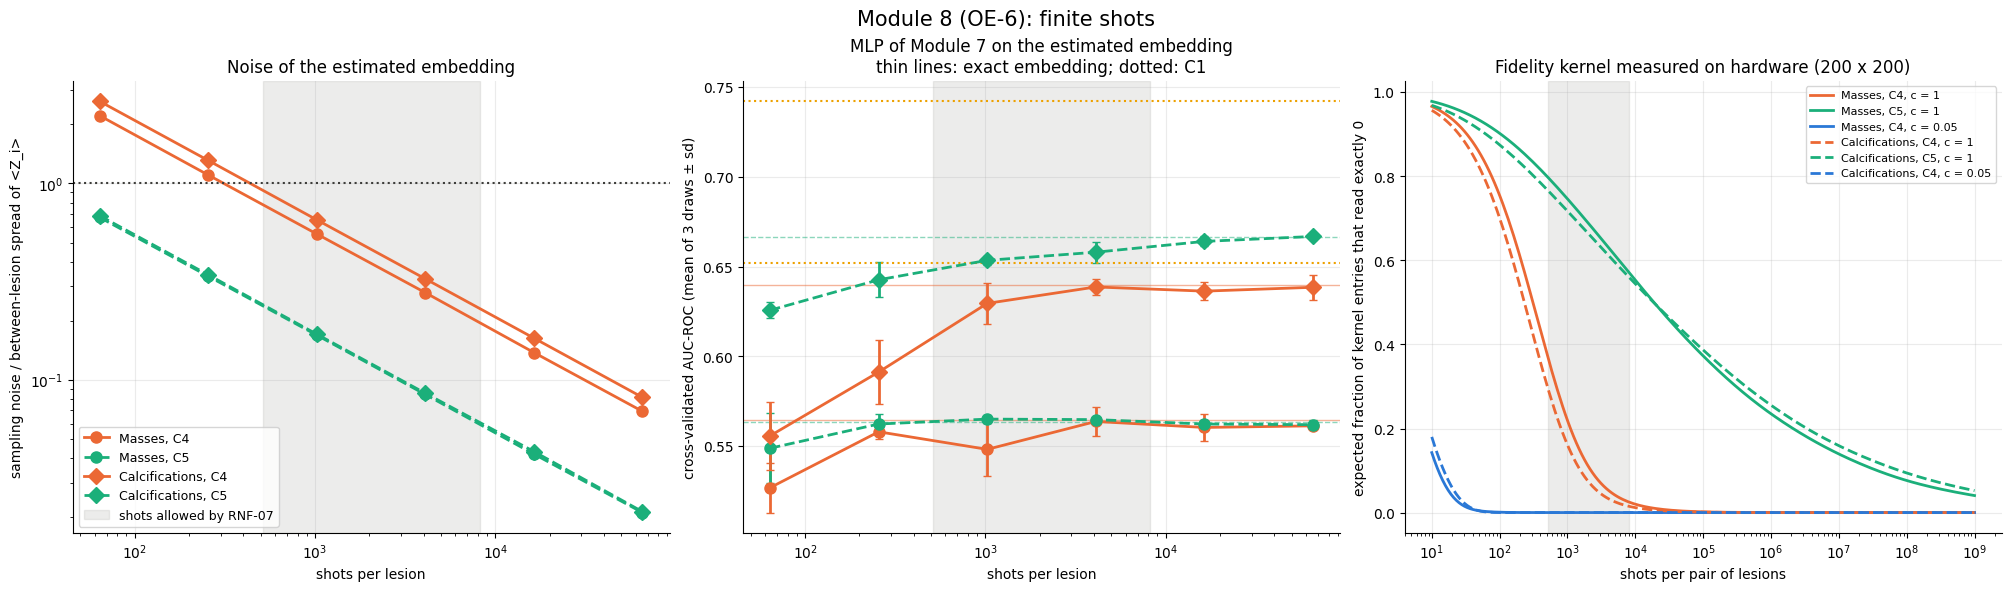

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.8), constrained_layout=True)
styles = {('mass', 'C4'): ('o', '-'), ('mass', 'C5'): ('o', '--'), ('calcification', 'C4'): ('D', '-'), ('calcification', 'C5'): ('D', '--')}
finite = summary[np.isfinite(summary.shots)]
for (ft, q), (m, ls) in styles.items():
    part = finite[(finite.finding_type == ft) & (finite['map'] == q)]
    axes[0].plot(part.shots, part.noise_over_spread, marker=m, ls=ls, color=COLORS[q], label=f'{TITLES[ft]}, {q}')
    axes[1].errorbar(part.shots, part.cv_auc, yerr=part.cv_auc_sd, marker=m, ls=ls, color=COLORS[q], capsize=3, label=f'{TITLES[ft]}, {q}')
    exact = summary[(summary.finding_type == ft) & (summary['map'] == q) & ~np.isfinite(summary.shots)].cv_auc.iloc[0]
    axes[1].axhline(exact, color=COLORS[q], ls=ls, lw=1, alpha=0.5)
for ax in axes[:2]:
    ax.axvspan(512, 8192, color='#b5b5b0', alpha=0.25, label='shots allowed by RNF-07')
    ax.set_xscale('log')
    ax.set_xlabel('shots per lesion')
axes[0].axhline(1, color=INK, ls=':', lw=1.5)
axes[0].set(yscale='log', ylabel='sampling noise / between-lesion spread of <Z_i>', title='Noise of the estimated embedding')
axes[0].legend(fontsize=9)
c1 = main_cv[main_cv.condition == 'C1'].groupby('finding_type').auc.mean()
for ft, m in [('mass', 'o'), ('calcification', 'D')]:
    axes[1].axhline(c1[ft], color=COLORS['C1'], ls=':', lw=1.5)
axes[1].set(ylabel='cross-validated AUC-ROC (mean of 3 draws ± sd)', title='MLP of Module 7 on the estimated embedding\nthin lines: exact embedding; dotted: C1')
ax = axes[2]
shots_grid = np.logspace(1, 9, 200)
for ft, m in [('mass', '-'), ('calcification', '--')]:
    z = np.load(M5_DIR / f'kernels_{ft}.npz', allow_pickle=True)
    iu = np.triu_indices(len(z['label']), 1)
    for q, c, color in [('C4', 1.0, COLORS['C4']), ('C5', 1.0, COLORS['C5']), ('C4', 0.05, '#2a78d6')]:
        v = z[f'K_Q_{q}_c{c}'][iu]
        ax.plot(shots_grid, [np.mean((1 - v) ** s) for s in shots_grid], m, color=color, label=f'{TITLES[ft]}, {q}, c = {c:g}')
ax.axvspan(512, 8192, color='#b5b5b0', alpha=0.25)
ax.set(xscale='log', xlabel='shots per pair of lesions', ylabel='expected fraction of kernel entries that read exactly 0',
       title='Fidelity kernel measured on hardware (200 x 200)')
ax.legend(fontsize=8)
fig.suptitle('Module 8 (OE-6): finite shots', fontsize=15)
fig.savefig(FIG_DIR / 'M8_oe6_shots.png', dpi=180, bbox_inches='tight')
plt.show()

**h.** The constraints of OE-6 in one table

In [20]:
k12 = cost[(cost.k == 12) & (cost.reps == 1)].iloc[0]
oe6 = []


def note(area, quantity, value, source):
    oe6.append({'area': area, 'quantity': quantity, 'value': value, 'source': source})


note('time', 'embedding per lesion, k = 12, direct statevector (Module 5)', f"{np.mean(list(m5_ms.values())):.1f} ms", '5a_resumen.csv')
note('time', 'one state, k = 12, AerSimulator', f"{measured[12] * 1000:.1f} ms", 'this module')
note('time', 'forward per lesion through EstimatorQNN, k = 12 (B1)', f"{k12.fwd_per_sample_s * 1000:.0f} ms", 'B1')
note('time', 'parameter-shift backward per lesion, k = 12 (B1)', f"{k12.bwd_per_sample_s:.1f} s ({int(k12.evaluations_per_gradient)} evaluations)", 'B1')
note('time', 'training theta, 50 epochs, both subsets, one map, k = 12 (B1)', f"{k12.training_hours_50_epochs_both_subsets_per_map:.0f} h", 'B1')
note('time', 'Architecture B against A, k = 12 (B1)', f"{b1_arch[b1_arch.k == 12].speedup.iloc[0]:.0f} times faster", 'B1')
note('time', 'kernel 200 x 200: statevector shortcut against compute-uncompute, per pair', f"{fq / pairs10 / (sv / pairs200):.0f} times faster", '5b_tiempos.csv')
note('qubits', 'largest k measured on this machine', f"{int(sweep.k.max())} ({measured[int(sweep.k.max())]:.1f} s per state)", 'this module')
for name, k in limits.items():
    note('qubits', f'largest viable k: {name}', str(k), 'this module (projection)')
for r in need.itertuples():
    note('shots, embedding', f'{TITLES[r.finding_type]} {r.map}: noise / spread at 1,024 shots (RNF-05)', f'{r.noise_over_spread_at_1024:.2f}', 'this module')
    note('shots, embedding', f'{TITLES[r.finding_type]} {r.map}: shots for noise = 10 % of the spread', f'{r.shots_noise_10pct_spread:,.0f}', 'this module')
for r in summary[summary.shots == 1024].itertuples():
    exact = summary[(summary.finding_type == r.finding_type) & (summary['map'] == r.map) & ~np.isfinite(summary.shots)].cv_auc.iloc[0]
    note('shots, classifier', f'{TITLES[r.finding_type]} {r.map}: CV AUC at 1,024 shots (exact)', f'{r.cv_auc:.3f} ({exact:.3f})', 'this module')
for r in kshots[kshots.c == 1.0].itertuples():
    note('shots, kernel', f'{TITLES[r.finding_type]} {r.map}, c = 1: entries that read 0 at 1,024 / 8,192 shots', f'{r.reads_zero_at_1024:.0%} / {r.reads_zero_at_8192:.0%}', 'this module')
    note('shots, kernel', f'{TITLES[r.finding_type]} {r.map}, c = 1: median shots per pair for a 10 % error', f'{r.median_shots_rel10:,.0f}', 'this module')
oe6 = pd.DataFrame(oe6)
oe6.to_csv(RESULTS_DIR / '8_oe6_resumen.csv', index=False)
pd.set_option('display.max_colwidth', 120)
display(oe6)

,area,quantity,value,source
0,time,"embedding per lesion, k = 12, direct statevector (Module 5)",8.1 ms,5a_resumen.csv
1,time,"one state, k = 12, AerSimulator",2.9 ms,this module
2,time,"forward per lesion through EstimatorQNN, k = 12 (B1)",93 ms,B1
3,time,"parameter-shift backward per lesion, k = 12 (B1)",4.7 s (48 evaluations),B1
4,time,"training theta, 50 epochs, both subsets, one map, k = 12 (B1)",191 h,B1
5,time,"Architecture B against A, k = 12 (B1)",1916 times faster,B1
6,time,"kernel 200 x 200: statevector shortcut against compute-uncompute, per pair",1422 times faster,5b_tiempos.csv
7,qubits,largest k measured on this machine,28 (74.8 s per state),this module
8,qubits,largest viable k: one state in memory (half of the RAM),29,this module (projection)
9,qubits,largest viable k: embedding of every lesion in 24 h,25,this module (projection)


#### **6° Verifications**

In [21]:
verifications = pd.DataFrame(checks)
verifications.to_csv(RESULTS_DIR / '8_verificaciones.csv', index=False)
display(verifications)
print(f'Checks passed: {int(verifications.passed.sum())}/{len(verifications)}')

,check,value,passed
0,the stored predictions reproduce every test AUC of Module 7,0.000000e+00,True
1,the stored out-of-fold predictions reproduce every fold AUC of Module 7,5.551115e-17,True
2,null control of Modules 6 and X3: C1 and C2 have the same embedding metrics,2.575717e-14,True
3,"the forest plot lists the same comparisons, in the same order, for both subsets",0.000000e+00,True
4,"without ties, Pearson on ranks equals the formula of the report",2.220446e-16,True
5,"with ties, Pearson on average ranks equals scipy.stats.spearmanr",1.110223e-16,True
6,no ties: the exact two-sided p of a perfect agreement is 2/120,1.666667e-02,True
7,C1 = C2 tied: the exact two-sided p of the best attainable agreement is 4/120,3.333333e-02,True
8,k = 12: ranking by the linear alignment equals ranking by its excess over the permutation mean (D-033),0.000000e+00,True
9,every separability ranking ties C1 and C2 (null control),0.000000e+00,True


Checks passed: 22/22


#### **7° Consequence**

**1. Classification (RF-20): no quantum model is significantly ahead of its classical reference.**

- **The preregistered comparison.** The same MLP loses between 0.07 and 0.14 of test AUC on C4 and C5 against C1, in both subsets. Every interval excludes zero except one, C5 against C3 in masses: −0.065 [−0.14, 0.002].
- **The exploratory kernel models.** They close the gap but never reverse it.
  - A QSVM on C4 cannot be told apart from the classical SVM: −0.021 [−0.05, 0.01] in masses and −0.010 [−0.04, 0.02] in calcifications.
  - C5 stays significantly below.
  - The nested search of X6, with the same protocol on both sides, ends in a tie on the test split: +0.004 and −0.005.
- **The figure** `M8_classical_vs_quantum.png` puts all of these differences on one axis.

**2. Separability against classification (RF-21, OE-5): the two rankings agree on what matters.**

| Primary $\rho_s$ (200-lesion subsample against test AUC, $k=12$) | Davies-Bouldin | Fisher $J$ | linear KTA |
|---|---|---|---|
| Masses | 0.72 (p = 0.17) | 0.82 (p = 0.13) | 0.72 (p = 0.17) |
| Calcifications | 0.97 (p = 0.033) | 0.67 (p = 0.27) | 0.97 (p = 0.033) |

- **All 48 coefficients are positive**, between 0.67 and 0.97. They cover three metrics, two samples, two evaluations, two subsets and two values of $k$.
- **In all of them, both rankings place the three classical conditions above the two quantum ones.** The agreement lives in that split.
- **Within each block the order is noise.** C1 and C2 differ in AUC only by the training noise (D-016), and C4 against C5 was never significant (H-042).
- **Five of the 48 values reach p < 0.05.** They are exactly the best order attainable with the C1 = C2 tie, $\rho_s = 0.975$ with p = 4/120. With 48 correlated values on the same five conditions, they are read as agreement, not as a test (D-039).
- **The kernel family.** The RBF kernel comes first both in alignment and in SVM test AUC. C4 and C5 swap places, but their alignment excesses differ by less than 0.003, so they are tied for practical purposes.

**What this answers.** OE-5 asked whether better separability translates into better classification. With these representations, separability and classification order the conditions in the same way. The premise of the hypothesis fails, though: the quantum transformations did not improve separability (Module 6), and the lower separability of C4 and C5 is followed by lower AUC. The correlation therefore supports the metrics of Module 6 as predictors, and it does not support an advantage.

**3. Masses against calcifications: the EDA was right about the classes and wrong about the features.**

| CV AUC of a logistic regression | Masses | Calcifications |
|---|---|---|
| Descriptors written by the radiologist | **0.872** | 0.825 |
| The 67 radiomic features (X1) | 0.693 | **0.800** |
| The 12 angles of Module 4 | 0.668 | 0.745 |

- **In the vocabulary of the radiologist, masses are the more separable subset**, as the EDA expected from shape and margins.
- **With the radiomic features the order reverses.** The 67 features recover almost everything the descriptors carry for calcifications (0.800 against 0.825), and much less for masses (0.693 against 0.872). The weakness of masses is therefore a property of the features, not of the classes.
- **A hypothesis to state, not a finding.** Margins (spiculated, ill-defined) are boundary details, and the features of Module 3 summarize the whole region and the outline of the mask. Testing it would need margin-specific features, and this work does not do that.
- **The quantum penalty is the same in both subsets.** C4 − C1 is −0.12 in masses and −0.14 in calcifications. The kernel geometry is also the same: median 0.002–0.003 for C4 and 0.00003 for C5, with *g* between 1.4 and 1.7. What differs between the subsets is the classical signal, not the quantum encoding.
- **The descriptors are a reference, not a competitor.** A radiologist wrote them while looking at the image, so no automatic system has them at prediction time.

**4. Constraints of the simulator (RF-22, OE-6).**

- **Time per sample.**
  - At $k=12$ one state takes 3 ms in `AerSimulator` and 8 ms with the direct statevector of Module 5.
  - Through `EstimatorQNN` it takes 93 ms (B1). The difference is overhead of the primitive, not physics.
  - Training θ by parameter-shift needs 48 evaluations per lesion: 4.7 s per lesion and about 191 h per feature map for 50 epochs (B1). That is why Architecture B, about 1,900 times faster, was the only feasible one (D-014).
- **Qubits.** Time and memory grow as $2^k$: about ×1.9 per added qubit above 20 on this machine, and 16 bytes × $2^k$ for the state.
  - Measured up to $k=28$: 75 s per state, 5.4 times the time at 26, above the trend of about 4. A first run of the same sweep gave 152 s at $k=28$. The times of the largest states depend on the load of the machine, so the limits below are uncertain by about one qubit (the first run gave 26, 23 and 15).
  - On this 16 GiB machine, the largest viable $k$ is:
    - 29 for one state in memory;
    - 25 for the embedding of every lesion within 24 h;
    - 22 for a 200 × 200 kernel by compute-uncompute;
    - 21 for the statevector shortcut, if all states are held at once;
    - 14 for training θ, as a lower bound that ignores the primitive overhead.
  - $k=12$ is far from every limit. The constraint that shaped the design was the gradient, not the number of qubits (H-011).
- **Shots and the embedding.**
  - At 1,024 shots, the minimum of RNF-05, the sampling noise of each ⟨Zᵢ⟩ is 55–65 % of the between-lesion spread for C4 and 17 % for C5. Reaching 10 % needs 31,000–44,000 shots for C4 and about 3,000 for C5.
  - Because the variance is $(1-\langle Z\rangle^2)/n$, the shots needed grow as 1/spread², so the more dispersed C5 is 10 to 15 times cheaper to measure.
  - The classifier tolerates this noise better than the coordinates do. At 1,024 shots the cross-validated AUC is within 0.02 of its exact value in the four cases. At 64 shots it loses up to 0.08 (calcifications, C4).
- **Shots and the kernel.** This is where hardware would fail.
  - At $c = 1$, with 1,024 shots per pair, 16–21 % of the C4 entries and 72–74 % of the C5 entries would read exactly 0. At 8,192 shots, 1.5–2.5 % and 56–57 %.
  - A 10 % relative error needs a median of 35,000–46,000 shots per pair for C4 and about 3 million for C5. 58–60 % of the C5 pairs need more than $10^6$.
  - Shrinking the angles ($c = 0.05$) lowers the cost to 400–630 shots per pair, but that is the regime where the kernel behaves classically (H-031).
  - **The concentration that made the kernel uninformative (Module 6) is the same property that makes it unmeasurable.**

**5. Formalism and implementation, kept apart for the report.**

- **Formalism.** These follow from quantum mechanics and hold on any machine:
  - the $2^k$ growth of the state;
  - the binomial law of a measured kernel entry;
  - the variance $(1-\langle Z\rangle^2)/n$ of a sampled expectation;
  - the $2m$ evaluations of the parameter-shift rule.
- **Implementation.** These belong to the simulator or to Qiskit, and the report puts them in §8.x:
  - the times on this machine;
  - the overhead of `EstimatorQNN`;
  - the default precision that adds Gaussian noise (H-019);
  - the statevector shortcut, which does not exist on hardware (H-032).

**Benefits and limitations, for §7.**

| Benefits | |
|---|---|
| A reproducible and audited protocol | 25 of 25 independent checks (H-046); the same protocol detects an advantage when the labels have one (H-048) |
| The encoding keeps the class information | A QSVM on C4 matches the classical SVM (H-044) |
| A feasible experiment on a laptop | Architecture B is about 1,900 times faster than training θ, and every quantum value is exact |

| Limitations | Where |
|---|---|
| Univariate selection does not see interactions, and going from 67 to 12 features costs 2–4 points of AUC | H-030, H-035 |
| Uncalibrated intensities, no pixel spacing: shape in pixels and a possible scanner confound | H-002, H-023, H-024 |
| The quantum kernel is concentrated at $c=1$ | H-031, H-037 |
| Architecture B loses information in the readout of 12 ⟨Zᵢ⟩ | H-044, D-014 |
| Ideal simulation: no hardware noise, and a statevector shortcut that hardware lacks | H-032, this module |
| Cross-validation slightly optimistic: selection and folds fitted on the whole training split | H-027 (effect ≤ 0.006, H-035) |
| Five conditions for Spearman; bootstrap intervals not adjusted for multiple comparisons | D-039, H-042 |
| Hyperparameters fixed a priori; protocol pending validation | D-036 |
| Decisions of Module 2 pending validation, and 7 discordant crops | D-020 to D-022 |

In [22]:
print('=' * 96)
print('MODULE 8 - COMPARATIVE EVALUATION - SUMMARY')
print('=' * 96)
for ft in FINDINGS:
    print(f'  {TITLES[ft]}')
    r = rf20[rf20.finding_type == ft].set_index('condition')
    print('    test AUC  ' + ' | '.join(f'{c} {r.loc[c, "test_auc"]:.3f}' for c in CONDITIONS))
    p = rho_table[rho_table.primary & (rho_table.finding_type == ft)]
    print('    Spearman (subsample vs test AUC, k = 12)  ' + ' | '.join(f'{x.metric} {x.rho:+.2f} (p = {x.p_exact_two_sided:.3f})' for x in p.itertuples()))
    print(f'    LR on radiologist descriptors: CV AUC {lr[(ft, "radiologist descriptors")]:.3f}; on the 67 radiomic features (X1): {lr[(ft, "X1: all 67 radiomic features")]:.3f}')
print('  OE-6')
for name, k in limits.items():
    print(f'    largest viable k, {name}: {k}')
for r in need.itertuples():
    print(f'    {TITLES[r.finding_type]:14s} {r.map}: noise/spread at 1,024 shots {r.noise_over_spread_at_1024:.2f}; shots for 10 %: {r.shots_noise_10pct_spread:,.0f}')
print(f"  Checks passed: {int(verifications.passed.sum())}/{len(verifications)}")
print('=' * 96)

MODULE 8 - COMPARATIVE EVALUATION - SUMMARY
  Masses
    test AUC  C1 0.651 | C2 0.641 | C3 0.646 | C4 0.530 | C5 0.581
    Spearman (subsample vs test AUC, k = 12)  Davies-Bouldin +0.72 (p = 0.167) | Fisher J +0.82 (p = 0.133) | linear KTA +0.72 (p = 0.167)
    LR on radiologist descriptors: CV AUC 0.872; on the 67 radiomic features (X1): 0.693
  Calcifications
    test AUC  C1 0.769 | C2 0.788 | C3 0.758 | C4 0.633 | C5 0.652
    Spearman (subsample vs test AUC, k = 12)  Davies-Bouldin +0.97 (p = 0.033) | Fisher J +0.67 (p = 0.267) | linear KTA +0.97 (p = 0.033)
    LR on radiologist descriptors: CV AUC 0.825; on the 67 radiomic features (X1): 0.800
  OE-6
    largest viable k, one state in memory (half of the RAM): 29
    largest viable k, embedding of every lesion in 24 h: 25
    largest viable k, kernel 200 x 200, compute-uncompute, in 24 h: 22
    largest viable k, kernel 200 x 200, statevector shortcut, all states in memory: 21
    largest viable k, training theta by parameter-s